# HPC Usage Statistics: User Perspective

This notebook visualises HPC cluster usage from a **user perspective**, focusing on **average efficiency metrics**. Average efficiency answers: "What's the typical job's efficiency?" — each job counts equally regardless of size.

**Use this notebook for:**
- User training and feedback sessions
- Identifying typical efficiency patterns and common issues
- Helping users understand how their jobs compare to others

For an infrastructure-focused view (weighted efficiency, where larger jobs contribute more), see `visualisation_infrastructure.ipynb`.

**Sections:**
1. [Overview](#1.-Overview) - Basic resource usage metrics by faculty
2. [Global Stats](#2.-Global-Stats) - Key metrics at a glance
3. [Detailed Analysis](#3.-Detailed-Analysis) - Comprehensive charts and comparisons
4. [Job-Level Distributions](#4.-Job-Level-Distributions) - Per-job efficiency patterns, correlations, and >100% analysis
5. [Why Efficiency Matters](#5.-Why-Efficiency-Matters) - Educational content
6. [Technical Appendix](#6.-Technical-Appendix) - Methodology

In [ ]:
# Setup and imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown

# Configuration: This notebook uses AVERAGE efficiency
EFFICIENCY_TYPE = 'average'
CPU_EFF_COL = 'avg_cpu_eff_req'
MEM_EFF_COL = 'avg_mem_eff'
TIME_EFF_COL = 'avg_time_eff'
NOTEBOOK_TITLE = 'User Perspective'

# --- Date range selection ---
# Set to a specific date range to select those files, e.g. "2025-07-01_2025-12-31"
# Set to None to automatically use the most recent files
DATE_FILTER = None

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100

In [ ]:
# Load data
import glob as _glob

# Find CSV files matching the date-range naming convention
RESULTS_DIR = '../results'

if DATE_FILTER:
    faculty_files = sorted(_glob.glob(f'{RESULTS_DIR}/{DATE_FILTER}_hpc_stats_output.csv'))
    job_files = sorted(_glob.glob(f'{RESULTS_DIR}/{DATE_FILTER}_job_level_metrics.csv'))
else:
    faculty_files = sorted(_glob.glob(f'{RESULTS_DIR}/*_hpc_stats_output.csv'))
    job_files = sorted(_glob.glob(f'{RESULTS_DIR}/*_job_level_metrics.csv'))

if not faculty_files:
    raise FileNotFoundError(
        f'No matching *_hpc_stats_output.csv found in {RESULTS_DIR}'
        + (f' for DATE_FILTER={DATE_FILTER!r}' if DATE_FILTER else ''))
if not job_files:
    raise FileNotFoundError(
        f'No matching *_job_level_metrics.csv found in {RESULTS_DIR}'
        + (f' for DATE_FILTER={DATE_FILTER!r}' if DATE_FILTER else ''))

FACULTY_STATS_PATH = faculty_files[-1]  # most recent
JOB_LEVEL_PATH = job_files[-1]

# Extract date range from CSV comment line, or fall back to filename
def _read_date_range(path):
    import re as _re
    with open(path) as f:
        first_line = f.readline().strip()
    if first_line.startswith('# date_range:'):
        return first_line.split(':', 1)[1].strip()
    # Fallback: extract from filename pattern like 2025-07-01_2025-12-31_*.csv
    m = _re.search(r'(\d{4}-\d{2}-\d{2})_(\d{4}-\d{2}-\d{2})_', path)
    if m:
        return f'{m.group(1)} to {m.group(2)}'
    return 'unknown'

DATE_RANGE = _read_date_range(FACULTY_STATS_PATH)
print(f'Date range: {DATE_RANGE}')
print(f'Faculty stats: {FACULTY_STATS_PATH}')
print(f'Job-level data: {JOB_LEVEL_PATH}')

df = pd.read_csv(FACULTY_STATS_PATH, comment='#')
df['faculty'] = df['faculty'].str.strip('"')
df_faculties = df[df['faculty'] != 'all'].copy()
df_global = df[df['faculty'] == 'all'].copy()

# Convert NULL strings to NaN
df_faculties = df_faculties.replace('NULL', np.nan)
for col in df_faculties.columns:
    if col != 'faculty':
        df_faculties[col] = pd.to_numeric(df_faculties[col], errors='coerce')

# Faculty name mapping
FACULTY_MERGE = {
    "Faculty of Life Sciences and Medicine": "Faculty of Life Sciences & Medicine",
    "IoPPN": "Institute of Psychiatry, Psychology & Neuroscience",
    "Dentistry, Oral & Craniofacial Sciences": "Faculty of Dentistry, Oral & Craniofacial Sciences",
    "Social Science & Public Policy": "Faculty of Social Science & Public Policy",
}

df_faculties['faculty'] = df_faculties['faculty'].replace(FACULTY_MERGE)

# --- Re-aggregate after faculty merge ---
df_faculties['_cpu_eff_denom'] = np.where(
    df_faculties['weighted_cpu_eff_req'] > 0,
    df_faculties['total_cpu_sec'] * 100 / df_faculties['weighted_cpu_eff_req'], 0)
df_faculties['_time_eff_denom'] = np.where(
    df_faculties['weighted_time_eff'] > 0,
    df_faculties['total_elapsed_sec'] * 100 / df_faculties['weighted_time_eff'], 0)

sum_cols = [
    'job_count', 'job_count_success', 'job_count_failed',
    'count_timeout', 'count_out_of_memory',
    'total_elapsed_sec', 'total_cpu_sec', 'total_user_cpu_sec', 'total_sys_cpu_sec',
    'total_maxrss_bytes', 'total_reqmem_bytes',
    'total_reqcpus', 'total_nodes', 'total_wait_sec',
    '_cpu_eff_denom', '_time_eff_denom',
]

avg_eff_cols = ['avg_cpu_eff_req', 'avg_cpu_eff_alloc', 'avg_mem_eff', 'avg_time_eff']
if 'avg_mem_eff_alloc' in df_faculties.columns:
    avg_eff_cols.append('avg_mem_eff_alloc')
for col in avg_eff_cols:
    df_faculties[f'_{col}_wsum'] = df_faculties[col].fillna(0) * df_faculties['job_count']
    sum_cols.append(f'_{col}_wsum')

df_faculties = df_faculties.groupby('faculty')[sum_cols].sum().reset_index()

# Recompute derived metrics
df_faculties['avg_elapsed_sec'] = df_faculties['total_elapsed_sec'] / df_faculties['job_count']
df_faculties['avg_cpu_sec'] = df_faculties['total_cpu_sec'] / df_faculties['job_count']
df_faculties['avg_maxrss_bytes'] = df_faculties['total_maxrss_bytes'] / df_faculties['job_count']
df_faculties['avg_reqmem_bytes'] = df_faculties['total_reqmem_bytes'] / df_faculties['job_count']
df_faculties['avg_reqcpus'] = df_faculties['total_reqcpus'] / df_faculties['job_count']
df_faculties['avg_wait_sec'] = df_faculties['total_wait_sec'] / df_faculties['job_count']

df_faculties['weighted_cpu_eff_req'] = np.where(
    df_faculties['_cpu_eff_denom'] > 0,
    df_faculties['total_cpu_sec'] / df_faculties['_cpu_eff_denom'] * 100, np.nan)
df_faculties['weighted_mem_eff'] = np.where(
    df_faculties['total_reqmem_bytes'] > 0,
    df_faculties['total_maxrss_bytes'] / df_faculties['total_reqmem_bytes'] * 100, np.nan)
df_faculties['weighted_time_eff'] = np.where(
    df_faculties['_time_eff_denom'] > 0,
    df_faculties['total_elapsed_sec'] / df_faculties['_time_eff_denom'] * 100, np.nan)

for col in avg_eff_cols:
    df_faculties[col] = df_faculties[f'_{col}_wsum'] / df_faculties['job_count']


df_faculties = df_faculties.drop(columns=[c for c in df_faculties.columns if c.startswith('_')])
df_plot = df_faculties.sort_values('job_count', ascending=True)

print(f"Loaded aggregate data: {len(df_faculties)} faculties")
print(f"Total jobs: {df_faculties['job_count'].sum():,}")

In [ ]:
# Shortened faculty names for plot labels
import textwrap

def _shorten_faculty(name):
    s = name.replace("Faculty of ", "").replace("Institute of ", "")
    return '\n'.join(textwrap.wrap(s, width=18))

df_faculties['faculty_short'] = df_faculties['faculty'].apply(_shorten_faculty)
FACULTY_SHORT = dict(zip(df_faculties['faculty'], df_faculties['faculty_short']))
df_plot = df_faculties.sort_values('job_count', ascending=True)

# Try to load per-job data
try:
    df_jobs = pd.read_csv(JOB_LEVEL_PATH, comment='#')
    if 'faculty' in df_jobs.columns:
        df_jobs['faculty'] = df_jobs['faculty'].str.strip('"')
        df_jobs['faculty'] = df_jobs['faculty'].replace(FACULTY_MERGE)
        df_jobs['faculty_short'] = df_jobs['faculty'].map(FACULTY_SHORT).fillna(df_jobs['faculty'])
    df_jobs = df_jobs.replace('NULL', np.nan)
    for col in ['cpu_eff_req', 'mem_eff', 'mem_eff_alloc', 'time_eff', 'wait_sec', 'elapsed_sec']:
        if col in df_jobs.columns:
            df_jobs[col] = pd.to_numeric(df_jobs[col], errors='coerce')
    HAS_JOB_DATA = True
    total_agg = df_faculties['job_count'].sum()
    print(f"Loaded per-job data: {len(df_jobs):,} jobs")
    if len(df_jobs) < total_agg:
        diff = total_agg - len(df_jobs)
        print(f"  Note: {diff:,} fewer than aggregate total ({total_agg:,}) because "
              f"job-level CSV includes only COMPLETED + TIMEOUT + OUT_OF_MEMORY jobs. "
              f"CANCELLED, FAILED, NODE_FAIL, and PREEMPTED jobs are excluded.")
except FileNotFoundError:
    HAS_JOB_DATA = False
    print(f"Note: {JOB_LEVEL_PATH} not found. Distribution analysis will be skipped.")

In [4]:
# Display date range prominently
display(Markdown(f"""
---
## Data period: {DATE_RANGE}

All plots and statistics in this notebook refer to jobs submitted during this period.

---
"""))


---
## Data period: 2025-07-01 to 2025-12-31

All plots and statistics in this notebook refer to jobs submitted during this period.

---


---
# 1. Overview

Basic resource usage metrics by faculty.

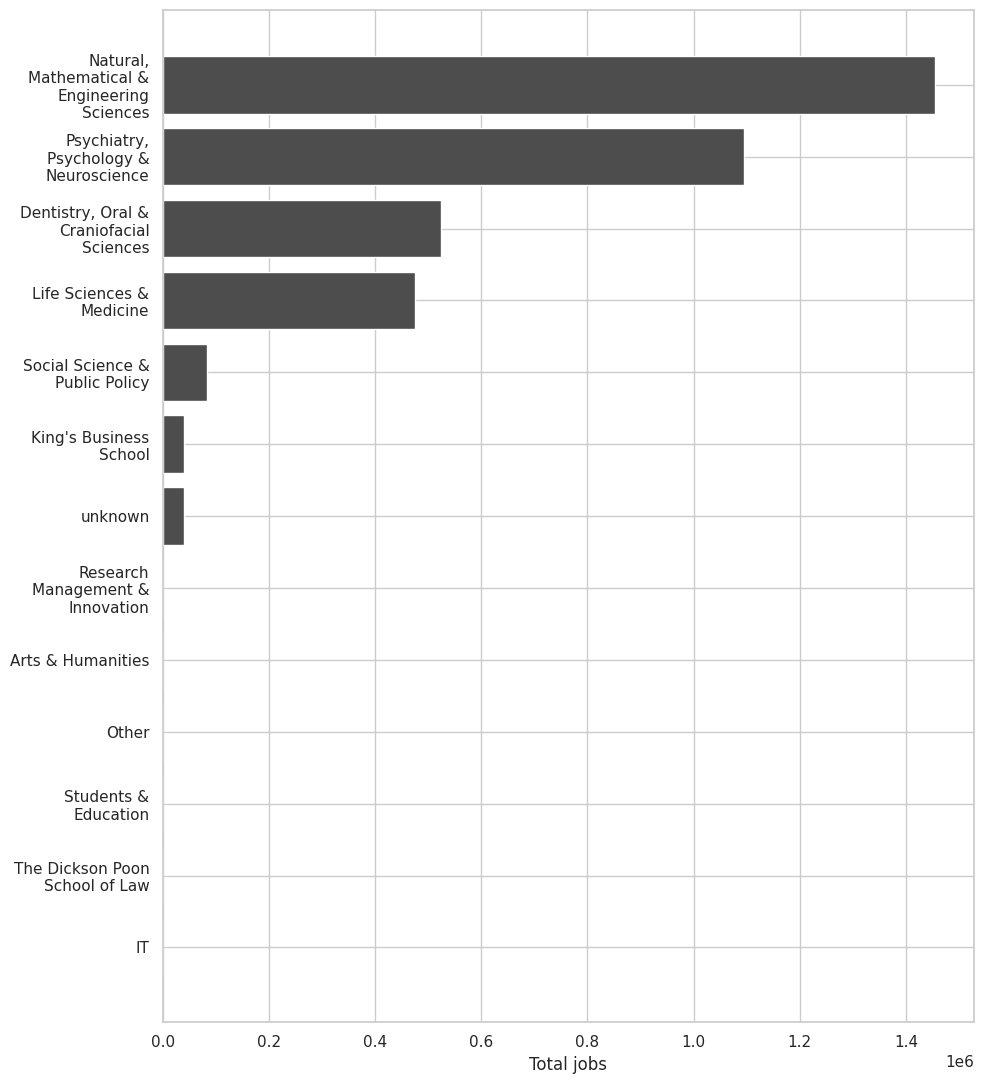

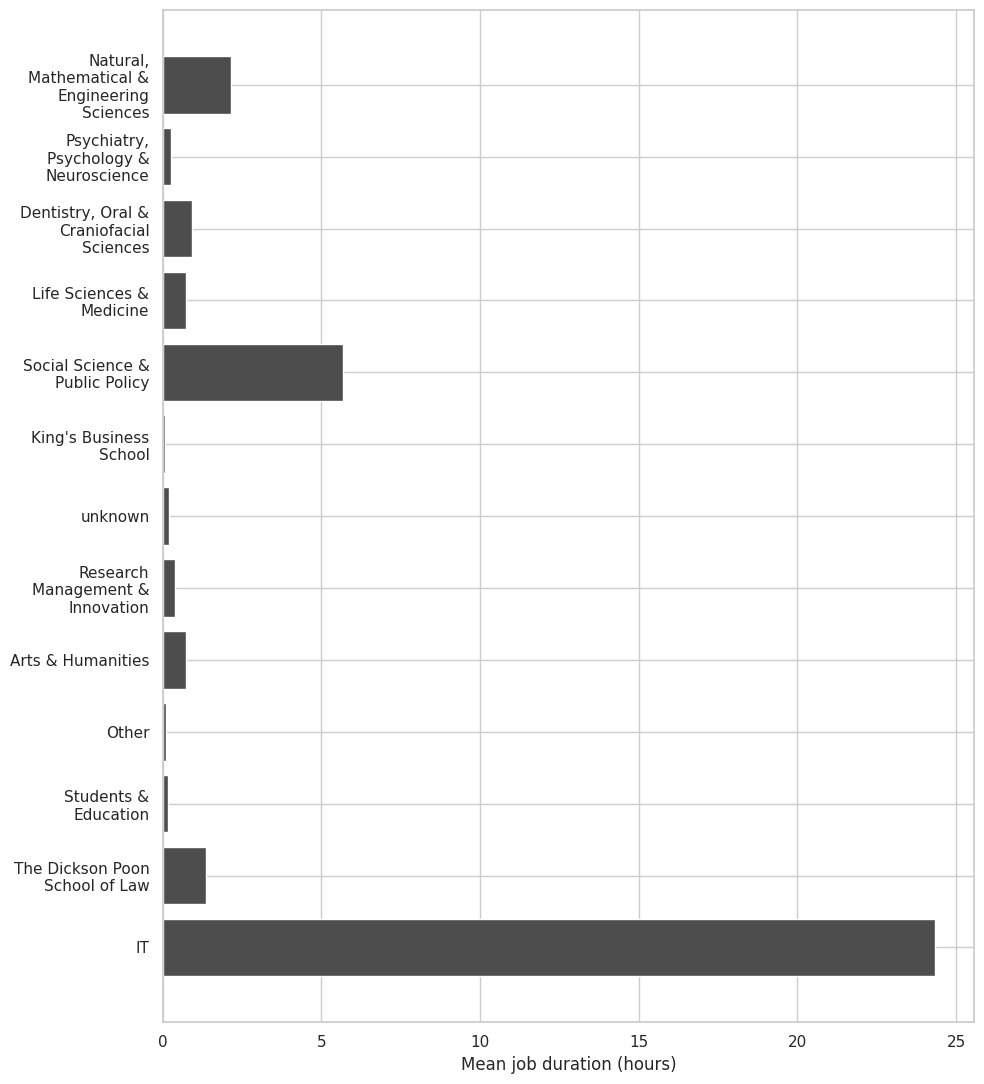

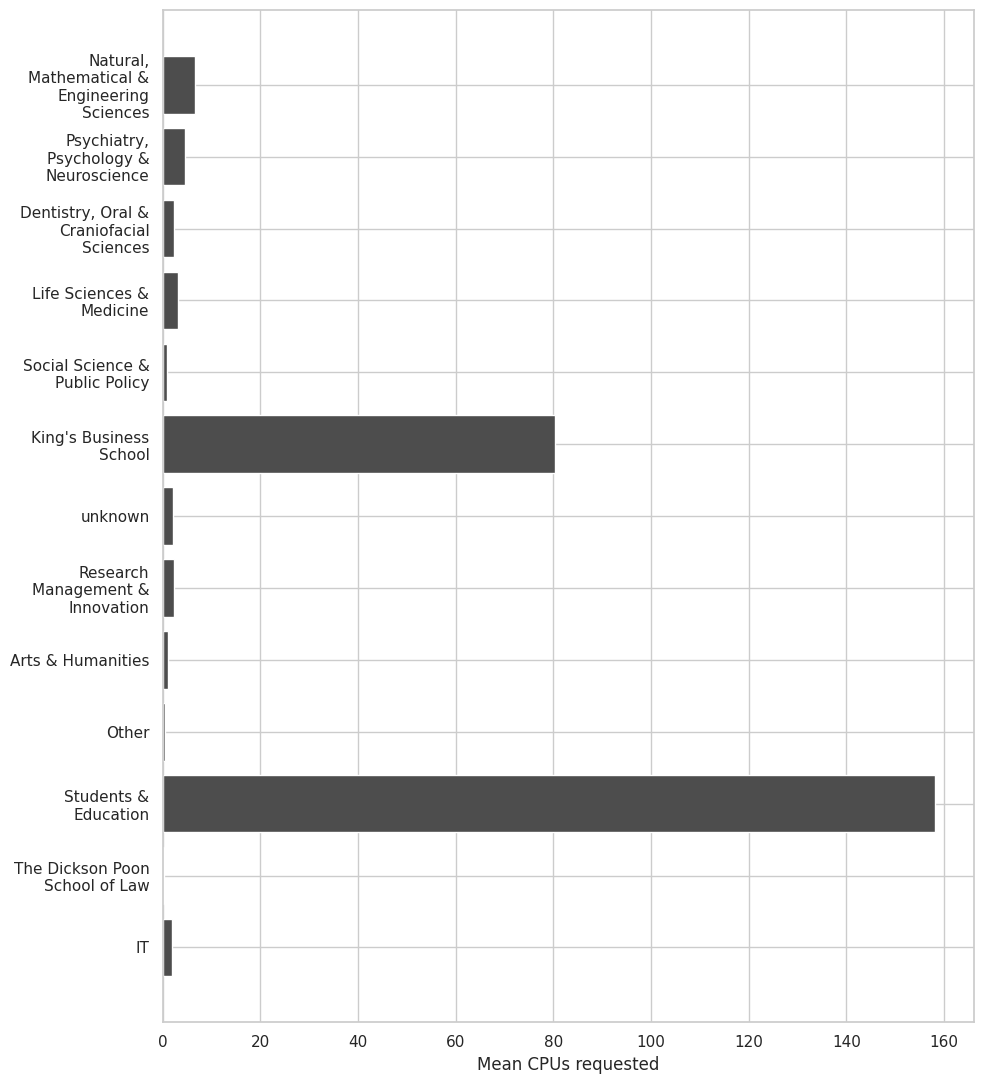

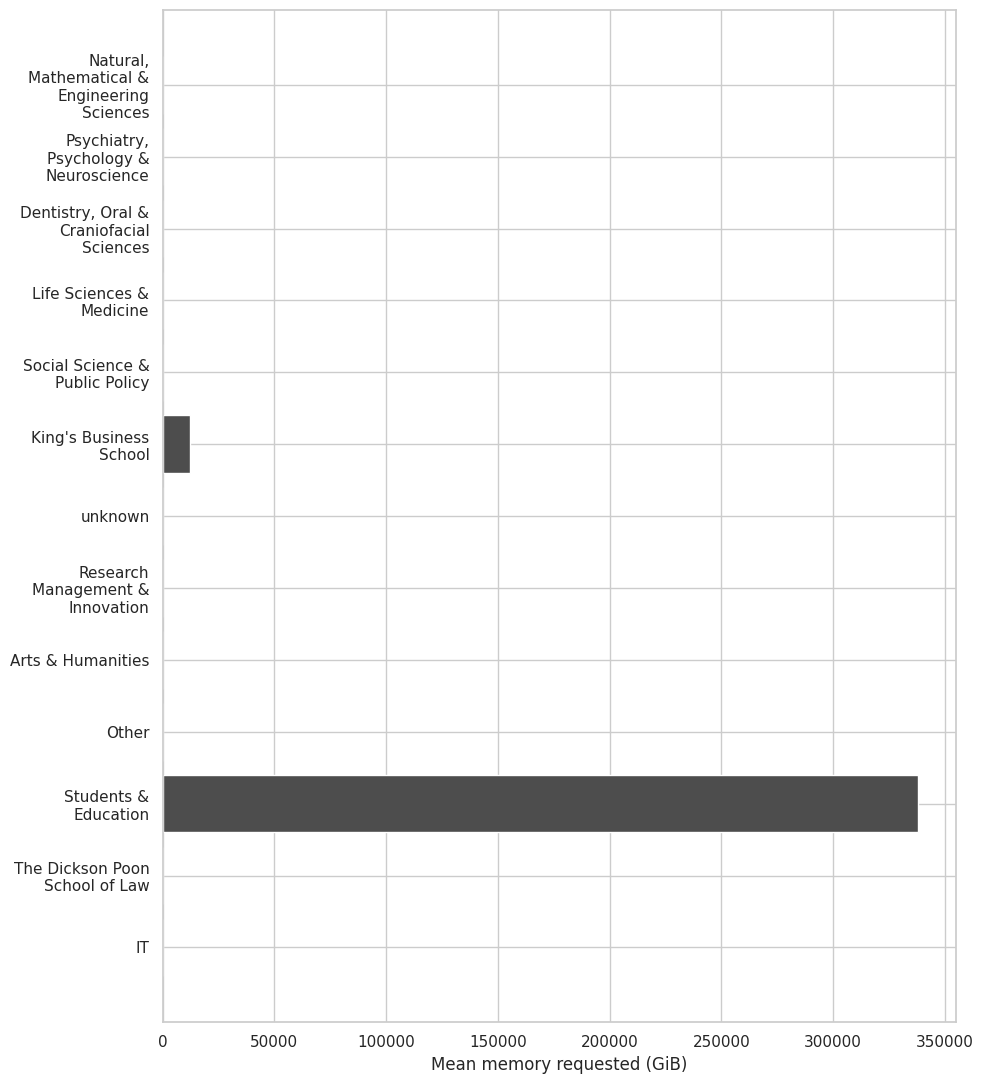

In [5]:
BAR_COLOR = '#4d4d4d'

def overview_bar(values, labels, xlabel):
    fig, ax = plt.subplots(figsize=(10, 11))
    ax.barh(labels, values, color=BAR_COLOR)
    ax.set_xlabel(xlabel)
    plt.tight_layout()
    plt.show()

overview_bar(df_plot['job_count'], df_plot['faculty_short'], 'Total jobs')
overview_bar(df_plot['avg_elapsed_sec'] / 3600, df_plot['faculty_short'], 'Mean job duration (hours)')
overview_bar(df_plot['avg_reqcpus'], df_plot['faculty_short'], 'Mean CPUs requested')
overview_bar(df_plot['avg_reqmem_bytes'] / (1024**3), df_plot['faculty_short'], 'Mean memory requested (GiB)')

---
# 2. Global Stats

Key metrics using **average efficiency** (mean across all jobs, each job counts equally).

In [6]:
def create_summary():
    total_jobs = df_faculties['job_count'].sum()
    total_success = df_faculties['job_count_success'].sum()
    success_rate = (total_success / total_jobs * 100) if total_jobs > 0 else 0
    
    # For average efficiency, compute job-weighted mean across faculties
    total_job_count = df_faculties['job_count'].sum()
    global_cpu_eff = (df_faculties[CPU_EFF_COL] * df_faculties['job_count']).sum() / total_job_count
    global_mem_eff = (df_faculties[MEM_EFF_COL] * df_faculties['job_count']).sum() / total_job_count
    
    if HAS_JOB_DATA and 'wait_sec' in df_jobs.columns:
        median_wait = df_jobs['wait_sec'].median() / 60
    else:
        median_wait = df_faculties['avg_wait_sec'].median() / 60
    
    summary = f"""
## Cluster-Wide Summary (Average Efficiency)

| Metric | Value |
|--------|-------|
| **Total Jobs** | {total_jobs:,} |
| **Success Rate** | {success_rate:.1f}% (COMPLETED only) |
| **CPU Efficiency** (average) | {global_cpu_eff:.1f}% |
| **Memory Efficiency** (average) | {global_mem_eff:.1f}% |
| **Median Queue Wait** | {median_wait:.1f} min |

*Average efficiency = mean of per-job efficiencies. Each job counts equally regardless of size.*
"""
    display(Markdown(summary))

create_summary()



## Cluster-Wide Summary (Average Efficiency)

| Metric | Value |
|--------|-------|
| **Total Jobs** | 3,717,485 |
| **Success Rate** | 76.3% (COMPLETED only) |
| **CPU Efficiency** (average) | 63.1% |
| **Memory Efficiency** (average) | 146.9% |
| **Median Queue Wait** | 5.0 min |

*Average efficiency = mean of per-job efficiencies. Each job counts equally regardless of size.*


In [7]:
def efficiency_ranking():
    ranking = df_faculties[['faculty', 'job_count', CPU_EFF_COL, MEM_EFF_COL, 'job_count_failed']].copy()
    ranking['failure_rate'] = (ranking['job_count_failed'] / ranking['job_count'] * 100).round(1)
    ranking = ranking.sort_values(CPU_EFF_COL, ascending=False)
    
    display(Markdown("### Faculty Ranking by Average CPU Efficiency"))
    display(Markdown("*Average efficiency shows typical job performance — each job counts equally.*"))
    display(ranking[['faculty', 'job_count', CPU_EFF_COL, MEM_EFF_COL, 'failure_rate']].round(2).rename(columns={
        'faculty': 'Faculty', 'job_count': 'Jobs', CPU_EFF_COL: 'CPU Eff %',
        MEM_EFF_COL: 'Mem Eff %', 'failure_rate': 'Failure %'
    }))

efficiency_ranking()

### Faculty Ranking by Average CPU Efficiency

*Average efficiency shows typical job performance — each job counts equally.*

,Faculty,Jobs,CPU Eff %,Mem Eff %,Failure %
4,Faculty of Social Science & Public Policy,82523,83.76,31.56,31.9
3,"Faculty of Natural, Mathematical & Engineering...",1455312,78.33,166.19,16.4
8,Other,298,77.18,79.52,37.6
1,"Faculty of Dentistry, Oral & Craniofacial Scie...",524149,63.39,246.12,8.1
11,The Dickson Poon School of Law,96,60.78,3055.99,47.9
2,Faculty of Life Sciences & Medicine,475915,58.74,101.97,26.1
6,"Institute of Psychiatry, Psychology & Neurosci...",1095733,46.47,108.42,6.4
0,Faculty of Arts & Humanities,581,37.73,3342.92,37.7
12,unknown,40741,37.47,67.12,58.0
9,Research Management & Innovation,798,24.80,98.15,33.2


**Column definitions:**
- **Jobs**: Total number of jobs submitted by the faculty
- **CPU Eff %**: Average CPU efficiency (mean of per-job efficiencies)
- **Mem Eff %**: Average memory efficiency (mean of per-job efficiencies)
- **Failure %**: Percentage of jobs that did not complete successfully (TIMEOUT + OUT_OF_MEMORY). Success = COMPLETED only.

**Observations:**

- **Faculty of Social Science & Public Policy**: Excellent CPU efficiency (88%) while submitting a substantial number of jobs (~22k). A model for efficient cluster usage.

- **Faculty of Natural, Mathematical & Engineering Sciences**: Good average efficiency (68%) — typical jobs are reasonably efficient. They submit the most jobs by far (~89k).

- **Faculty of Arts & Humanities**: Moderate CPU efficiency (36%), but very high memory efficiency values and a high failure rate (43%). The sample size is very small (28 jobs), so not statistically representative.

---
# 3. Detailed Analysis

## 3.1 Average Efficiency by Faculty

In [ ]:
def faculty_ci_stats(col):
    """Compute per-faculty mean and 95% CI from job-level data."""
    if not HAS_JOB_DATA or 'faculty' not in df_jobs.columns:
        return pd.DataFrame()
    rows = []
    for fac in df_jobs['faculty'].unique():
        vals = df_jobs.loc[df_jobs['faculty'] == fac, col].dropna()
        if len(vals) < 5:
            continue
        mean = vals.mean()
        se = vals.std() / np.sqrt(len(vals))
        ci = 1.96 * se
        rows.append({
            'faculty': fac,
            'faculty_short': FACULTY_SHORT.get(fac, fac),
            'mean': mean,
            'ci': ci,
            'n': len(vals),
        })
    return pd.DataFrame(rows).sort_values('mean', ascending=True)

def plot_efficiency():
    if not HAS_JOB_DATA or 'faculty' not in df_jobs.columns:
        print("Per-job data with faculty not available.")
        return

    cpu_fstats = faculty_ci_stats('cpu_eff_req')
    mem_fstats = faculty_ci_stats('mem_eff')

    fig, axes = plt.subplots(1, 2, figsize=(18, max(8, len(cpu_fstats) * 0.6)))

    for ax, fstats, color, title in [
        (axes[0], cpu_fstats, '#2196f3', 'Average CPU Efficiency by Faculty'),
        (axes[1], mem_fstats, '#4caf50', 'Average Memory Efficiency by Faculty'),
    ]:
        y = range(len(fstats))
        ax.barh(y, fstats['mean'], xerr=fstats['ci'],
                color=color, alpha=0.7, edgecolor='white',
                capsize=3, error_kw={'lw': 1})
        ax.set_yticks(list(y))
        ax.set_yticklabels(fstats['faculty_short'], fontsize=9)
        ax.set_xlabel('Efficiency (%)')
        ax.set_title(title)
        ax.axvline(50, color='orange', ls='--', alpha=0.4)
        ax.axvline(100, color='green', ls='--', alpha=0.4)

        for i, (_, row) in enumerate(fstats.iterrows()):
            ax.text(row['mean'] + row['ci'] + 1, i,
                    f'{row["n"]:,}', va='center', fontsize=10)

    plt.suptitle(f'Faculty Efficiency Rankings with 95% CI ({DATE_RANGE})',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    display(Markdown('''
*Numbers at the tip of each bar indicate the number of jobs included.
Error bars show 95% confidence intervals around the mean.*
'''))

plot_efficiency()

Excluded 2 outlier faculties (avg mem eff > 500%): Faculty of Arts & Humanities, The Dickson Poon School of Law


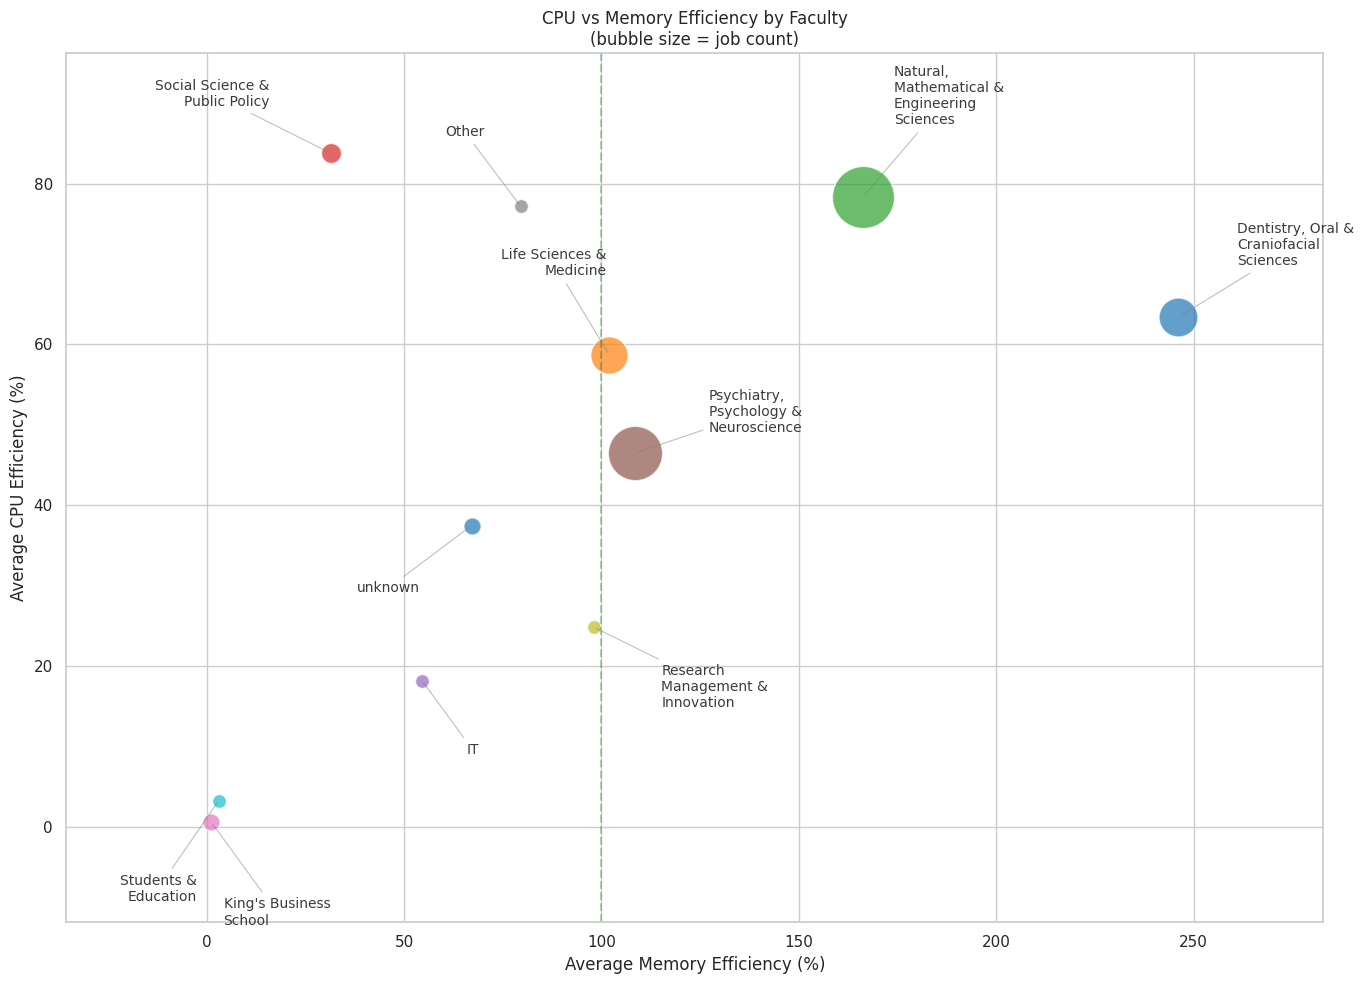

In [9]:
def plot_faculty_cpu_vs_mem_scatter():
    """Scatter plot of average CPU vs Memory efficiency by faculty.
    Bubble size proportional to job count. Outlier faculties excluded."""
    plot_df = df_faculties[['faculty', 'faculty_short', 'job_count',
                            CPU_EFF_COL, MEM_EFF_COL]].copy()
    plot_df = plot_df.dropna(subset=[CPU_EFF_COL, MEM_EFF_COL])

    # Exclude outlier faculties (extreme memory efficiency values)
    excluded = plot_df[plot_df[MEM_EFF_COL] > 500]
    if len(excluded) > 0:
        excluded_names = excluded['faculty'].tolist()
        print(f"Excluded {len(excluded)} outlier faculties "
              f"(avg mem eff > 500%): {', '.join(excluded_names)}")
    plot_df = plot_df[plot_df[MEM_EFF_COL] <= 500].reset_index(drop=True)

    if len(plot_df) == 0:
        print("No faculties remaining after outlier removal.")
        return

    # Scale bubble sizes
    min_size, max_size = 100, 2000
    jc = plot_df['job_count']
    if jc.max() > jc.min():
        sizes = min_size + (jc - jc.min()) / (jc.max() - jc.min()) * (max_size - min_size)
    else:
        sizes = pd.Series([min_size] * len(plot_df))

    palette = sns.color_palette('tab10', n_colors=len(plot_df))

    fig, ax = plt.subplots(figsize=(14, 10))
    for i, (_, row) in enumerate(plot_df.iterrows()):
        ax.scatter(row[MEM_EFF_COL], row[CPU_EFF_COL],
                   s=sizes.iloc[i], alpha=0.7, color=palette[i],
                   edgecolors='white', linewidth=1)

    # Normalize coordinates to [0,1] for angle computation
    x_vals = plot_df[MEM_EFF_COL].values
    y_vals = plot_df[CPU_EFF_COL].values
    x_range = x_vals.max() - x_vals.min() if x_vals.max() > x_vals.min() else 1
    y_range = y_vals.max() - y_vals.min() if y_vals.max() > y_vals.min() else 1
    x_norm = (x_vals - x_vals.min()) / x_range
    y_norm = (y_vals - y_vals.min()) / y_range

    # Compute angle from centroid for each point
    cx, cy = x_norm.mean(), y_norm.mean()
    raw_angles = np.arctan2(y_norm - cy, x_norm - cx)

    # Sort by angle, then enforce minimum separation
    order = np.argsort(raw_angles)
    sorted_angles = raw_angles[order]
    min_sep = 2 * np.pi / len(plot_df) * 0.8  # ~80% of even spacing
    adjusted = sorted_angles.copy()
    for j in range(1, len(adjusted)):
        if adjusted[j] - adjusted[j-1] < min_sep:
            adjusted[j] = adjusted[j-1] + min_sep
    # Map back to original order
    final_angles = np.empty_like(raw_angles)
    for j, idx_j in enumerate(order):
        final_angles[idx_j] = adjusted[j]

    offset_dist = 55
    for i, (_, row) in enumerate(plot_df.iterrows()):
        x, y = row[MEM_EFF_COL], row[CPU_EFF_COL]
        label = row['faculty_short']
        angle = final_angles[i]
        dx = offset_dist * np.cos(angle)
        dy = offset_dist * np.sin(angle)
        ha = 'left' if dx >= 0 else 'right'
        va = 'bottom' if dy >= 0 else 'top'
        ax.annotate(label, (x, y),
                    textcoords='offset points', xytext=(dx, dy),
                    fontsize=10, ha=ha, va=va, alpha=0.9,
                    arrowprops=dict(arrowstyle='-', color='grey', alpha=0.5, lw=0.8))

    ax.axhline(y=100, color='green', linestyle='--', alpha=0.3)
    ax.axvline(x=100, color='green', linestyle='--', alpha=0.3)
    ax.set_xlabel('Average Memory Efficiency (%)')
    ax.set_ylabel('Average CPU Efficiency (%)')
    ax.set_title('CPU vs Memory Efficiency by Faculty\n(bubble size = job count)')
    # Add margin for labels
    x_margin = x_range * 0.15
    y_margin = y_range * 0.15
    ax.set_xlim(x_vals.min() - x_margin, x_vals.max() + x_margin)
    ax.set_ylim(y_vals.min() - y_margin, y_vals.max() + y_margin)
    plt.tight_layout()
    plt.show()

plot_faculty_cpu_vs_mem_scatter()


## 3.2 Job Success/Failure

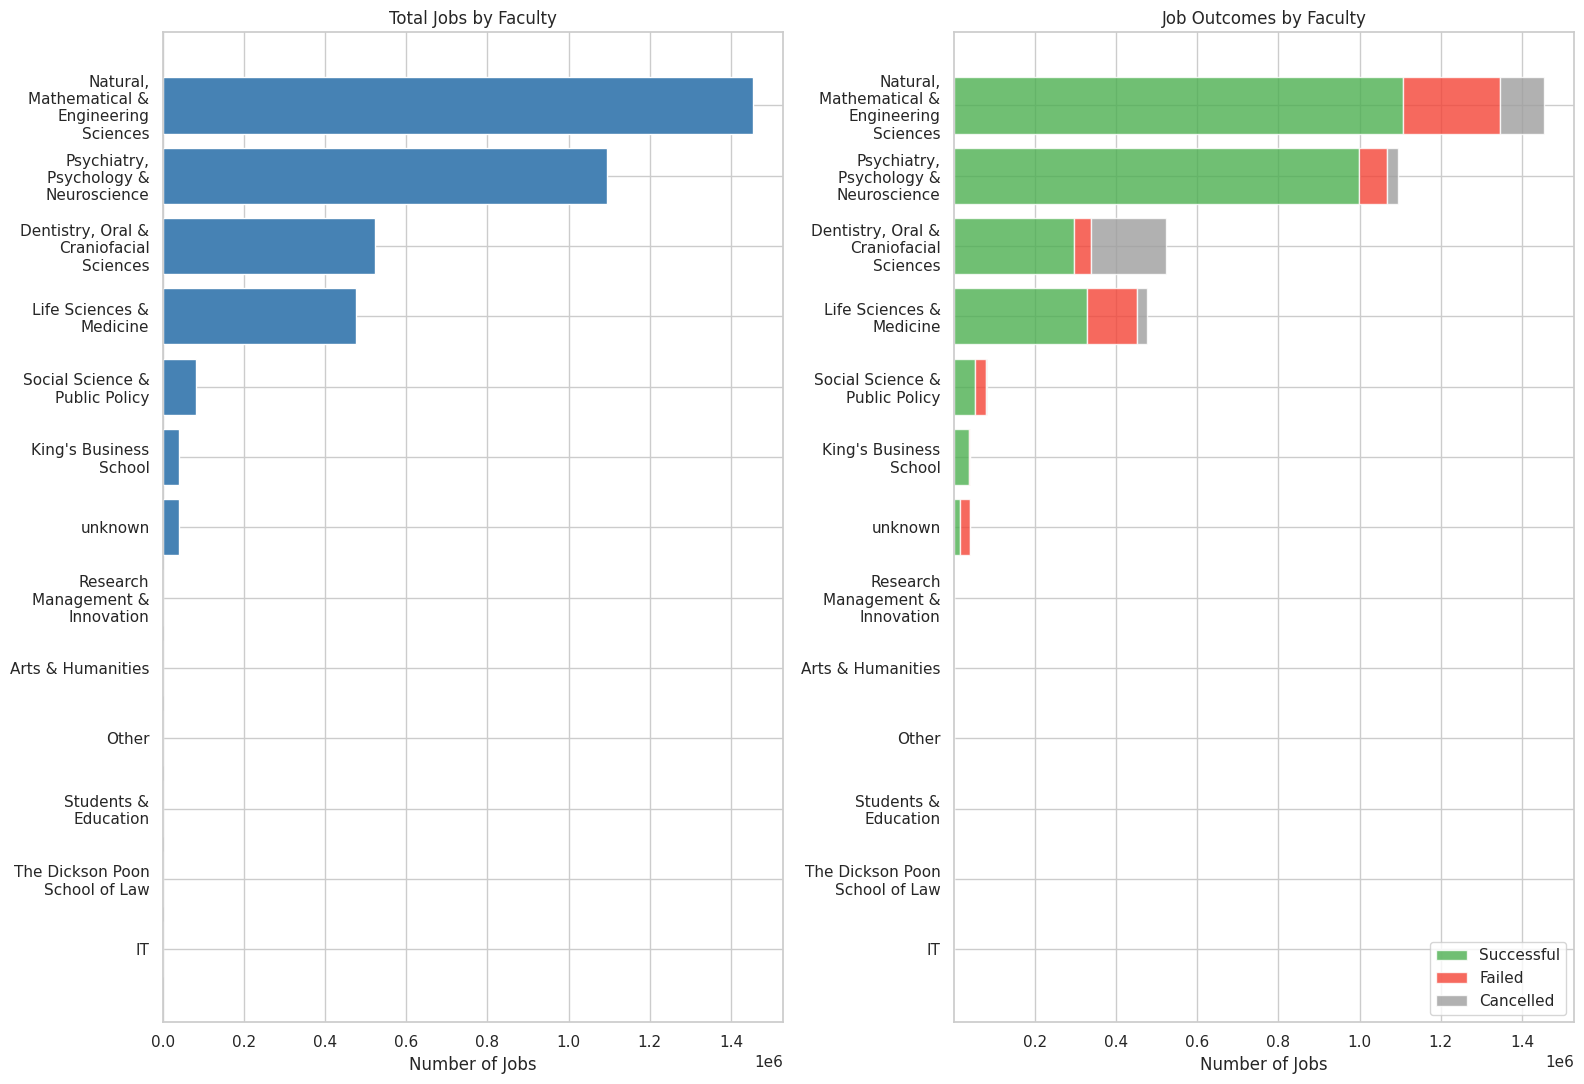


**Note on job categories:**
- **Successful** = COMPLETED only
- **Failed** = FAILED, TIMEOUT, NODE_FAIL, PREEMPTED, OUT_OF_MEMORY
- **Cancelled** = jobs cancelled by the user (intentional action, excluded from failure count)

All three categories sum to the total job count shown on the left.


In [10]:
def plot_job_counts():
    fig, axes = plt.subplots(1, 2, figsize=(16, 11))
    sorted_df = df_faculties.sort_values('job_count', ascending=True)
    
    axes[0].barh(sorted_df['faculty_short'], sorted_df['job_count'], color='steelblue')
    axes[0].set_xlabel('Number of Jobs')
    axes[0].set_title('Total Jobs by Faculty')
    
    other = sorted_df['job_count'] - sorted_df['job_count_success'] - sorted_df['job_count_failed']
    axes[1].barh(sorted_df['faculty_short'], sorted_df['job_count_success'], 
                 label='Successful', color='#4caf50', alpha=0.8)
    axes[1].barh(sorted_df['faculty_short'], sorted_df['job_count_failed'], 
                 left=sorted_df['job_count_success'], label='Failed', color='#f44336', alpha=0.8)
    axes[1].barh(sorted_df['faculty_short'], other,
                 left=sorted_df['job_count_success'] + sorted_df['job_count_failed'],
                 label='Cancelled', color='#9e9e9e', alpha=0.8)
    axes[1].set_xlabel('Number of Jobs')
    axes[1].set_title('Job Outcomes by Faculty')
    axes[1].legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()

plot_job_counts()

display(Markdown("""
**Note on job categories:**
- **Successful** = COMPLETED only
- **Failed** = FAILED, TIMEOUT, NODE_FAIL, PREEMPTED, OUT_OF_MEMORY
- **Cancelled** = jobs cancelled by the user (intentional action, excluded from failure count)

All three categories sum to the total job count shown on the left.
"""))


---
# 4. Job-Level Distributions

Understanding the **distribution** of efficiency across jobs helps identify common patterns and outliers. This section uses per-job data to show the full range of job efficiency.

## 4.1 Efficiency Distributions

Violin plots show the distribution of efficiency within each faculty. All violins are scaled to the same maximum width, so their shapes show the *relative* distribution within each faculty.

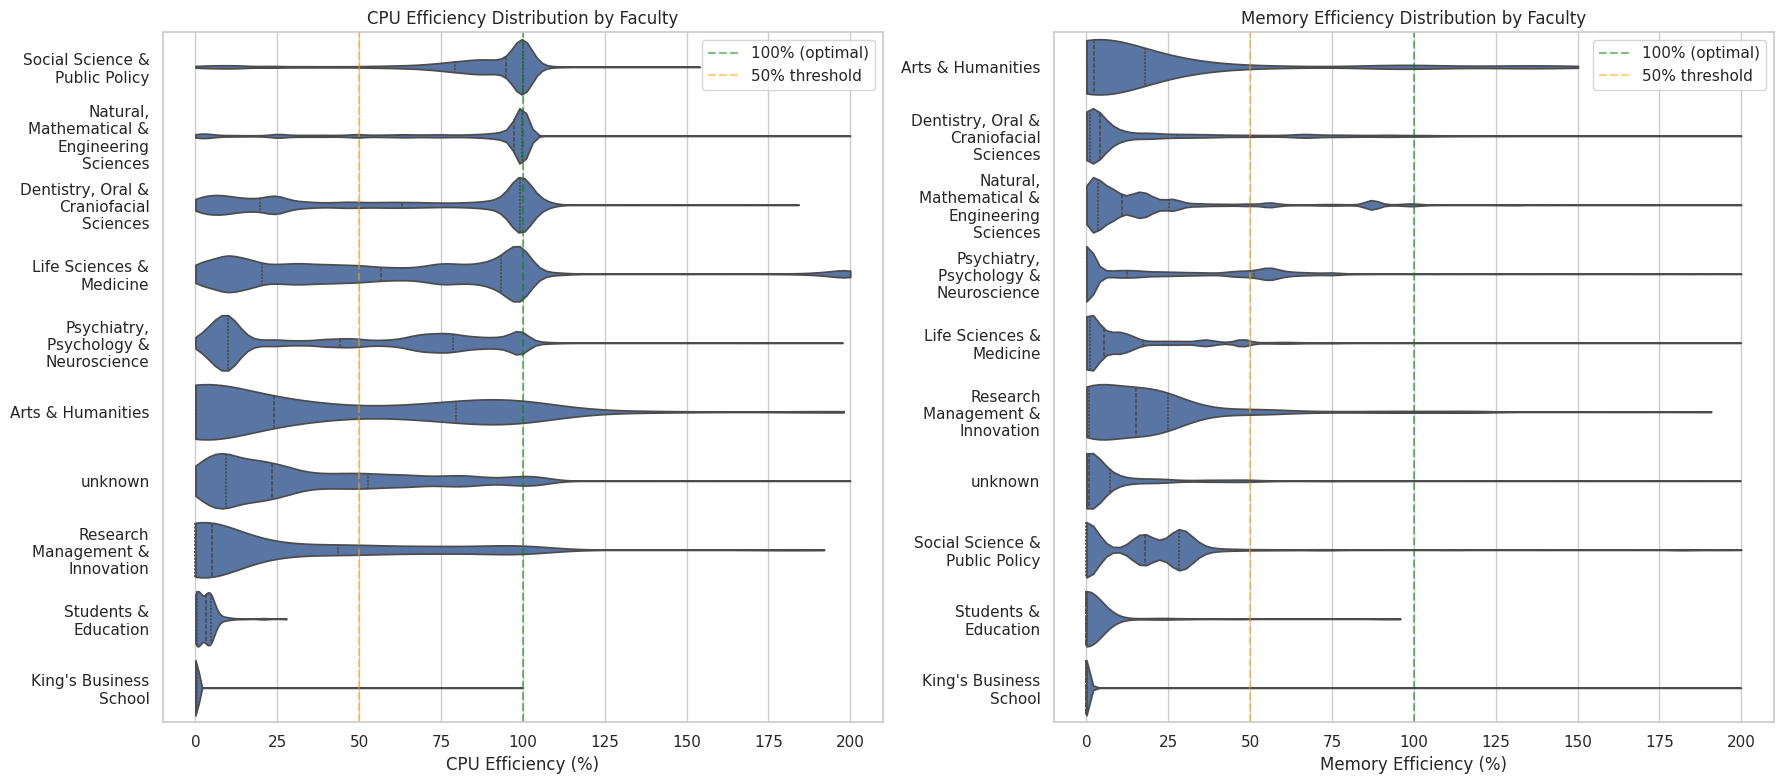

In [11]:
def plot_violin_efficiency():
    """Side-by-side violin plots of CPU and memory efficiency by faculty."""
    if not HAS_JOB_DATA:
        print("Per-job data not available. Run hpc-job-stats first.")
        return
    if 'faculty' not in df_jobs.columns:
        print("Faculty column not in job data. Run hpc-job-stats with --include-faculty.")
        return

    top_faculties = df_jobs['faculty'].value_counts().head(10).index.tolist()

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    # Left: CPU efficiency, ordered by avg CPU efficiency
    cpu_data = df_jobs[df_jobs['cpu_eff_req'].notna() & (df_jobs['cpu_eff_req'] <= 200)].copy()
    cpu_data = cpu_data[cpu_data['faculty'].isin(top_faculties)]
    cpu_ranking = (df_faculties[df_faculties['faculty'].isin(top_faculties)]
                   .sort_values(CPU_EFF_COL, ascending=False))
    cpu_order = [FACULTY_SHORT.get(f, f) for f in cpu_ranking['faculty']]

    sns.violinplot(data=cpu_data, y='faculty_short', x='cpu_eff_req', ax=axes[0],
                   cut=0, order=cpu_order, density_norm='width', inner='quartile')
    axes[0].axvline(x=100, color='green', linestyle='--', alpha=0.5, label='100% (optimal)')
    axes[0].axvline(x=50, color='orange', linestyle='--', alpha=0.5, label='50% threshold')
    axes[0].set_ylabel('')
    axes[0].set_xlabel('CPU Efficiency (%)')
    axes[0].set_title('CPU Efficiency Distribution by Faculty')
    axes[0].legend()

    # Right: Memory efficiency, ordered by avg memory efficiency
    mem_data = df_jobs[df_jobs['mem_eff'].notna() & (df_jobs['mem_eff'] <= 200)].copy()
    mem_data = mem_data[mem_data['faculty'].isin(top_faculties)]
    mem_ranking = (df_faculties[df_faculties['faculty'].isin(top_faculties)]
                   .sort_values(MEM_EFF_COL, ascending=False))
    mem_order = [FACULTY_SHORT.get(f, f) for f in mem_ranking['faculty']]

    sns.violinplot(data=mem_data, y='faculty_short', x='mem_eff', ax=axes[1],
                   cut=0, order=mem_order, density_norm='width', inner='quartile')
    axes[1].axvline(x=100, color='green', linestyle='--', alpha=0.5, label='100% (optimal)')
    axes[1].axvline(x=50, color='orange', linestyle='--', alpha=0.5, label='50% threshold')
    axes[1].set_ylabel('')
    axes[1].set_xlabel('Memory Efficiency (%)')
    axes[1].set_title('Memory Efficiency Distribution by Faculty')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_violin_efficiency()


In [ ]:
def plot_wait_time_distribution():
    """Histogram of wait times."""
    if not HAS_JOB_DATA:
        print("Per-job data not available.")
        return
    
    wait_data = df_jobs['wait_sec'].dropna()
    wait_minutes = wait_data / 60
    
    median = wait_minutes.median()
    mean = wait_minutes.mean()
    p95 = wait_minutes.quantile(0.95)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    axes[0].hist(wait_minutes, bins=100, color='steelblue', alpha=0.7, edgecolor='white')
    axes[0].axvline(median, color='green', linestyle='--', linewidth=2, label=f'Median: {median:.1f} min')
    axes[0].axvline(mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean:.1f} min')
    axes[0].set_xlabel('Wait Time (minutes)')
    axes[0].set_ylabel('Number of Jobs')
    axes[0].set_title('Wait Time Distribution')
    axes[0].set_yscale('log')
    axes[0].yaxis.set_major_formatter(mticker.ScalarFormatter())
    axes[0].legend()
    
    zoomed = wait_minutes[wait_minutes <= p95]
    axes[1].hist(zoomed, bins=50, color='#ff9800', alpha=0.7, edgecolor='white')
    axes[1].axvline(median, color='green', linestyle='--', linewidth=2, label=f'Median: {median:.1f} min')
    axes[1].set_xlabel('Wait Time (minutes)')
    axes[1].set_ylabel('Number of Jobs')
    axes[1].set_title(f'Wait Time (≤ 95th percentile: {p95:.0f} min)')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    display(Markdown(f"""
**Your typical wait time:** Most jobs ({len(zoomed)/len(wait_minutes)*100:.0f}%) wait less than **{p95:.0f} minutes**.
The median wait is **{median:.1f} minutes** — half of all jobs start faster than this.
"""))

plot_wait_time_distribution()

**Left plot:** Full distribution on a **log scale** — reveals the long tail of jobs with very long wait times.

**Right plot:** Zoomed to the **95th percentile** on a linear scale — shows the typical wait time experience for the majority of jobs.

## 4.2 Nodes Requested Distribution

In [ ]:
def plot_nodes_distribution():
    """Distribution of nodes requested per job."""
    if not HAS_JOB_DATA:
        print("Per-job data not available.")
        return

    nodes = pd.to_numeric(df_jobs['n_nodes'], errors='coerce').dropna()
    nodes = nodes[nodes > 0]

    n_single = (nodes == 1).sum()
    n_multi = (nodes > 1).sum()
    pct_single = n_single / len(nodes) * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: bar chart of most common node counts
    top_vals = nodes.value_counts().head(15).sort_index()
    axes[0].bar(top_vals.index.astype(int).astype(str), top_vals.values,
                color='steelblue', alpha=0.7, edgecolor='white')
    axes[0].set_xlabel('Number of Nodes')
    axes[0].set_ylabel('Number of Jobs')
    axes[0].set_title(f'Most common node counts (top 15 values)')
    for i, (val, count) in enumerate(top_vals.items()):
        pct = count / len(nodes) * 100
        if pct >= 1:
            axes[0].text(i, count, f'{pct:.1f}%', ha='center', va='bottom', fontsize=8)

    # Right: multi-node jobs only (zoomed)
    multi = nodes[nodes > 1]
    if len(multi) > 0:
        top_multi = int(multi.quantile(0.99)) if len(multi) > 10 else int(multi.max())
        axes[1].hist(multi[multi <= top_multi], bins=range(2, top_multi + 2),
                     color='#ff9800', alpha=0.7, edgecolor='white')
        axes[1].set_xlabel('Number of Nodes')
        axes[1].set_ylabel('Number of Jobs')
        axes[1].set_title(f'Multi-node jobs only (n = {n_multi:,})')
    else:
        axes[1].text(0.5, 0.5, 'No multi-node jobs', transform=axes[1].transAxes,
                     ha='center', fontsize=14)

    plt.suptitle('Distribution of Nodes per Job', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    display(Markdown(f'''
**Summary:** Of **{len(nodes):,}** jobs, **{n_single:,}** ({pct_single:.1f}%) used a single node
and **{n_multi:,}** ({100 - pct_single:.1f}%) used multiple nodes.

| Stat | Value |
|------|-------|
| Median | {nodes.median():.0f} |
| Mean | {nodes.mean():.2f} |
| Max | {nodes.max():.0f} |
| % single-node | {pct_single:.1f}% |
'''))

plot_nodes_distribution()

## 4.3 Correlation Analysis

Exploring relationships between job-level metrics. Since efficiency distributions are typically non-normal (heavily skewed), we use **Spearman rank correlation** rather than Pearson.

### Normality Test

In [13]:
def normality_test():
    """Test whether efficiency distributions are normally distributed."""
    if not HAS_JOB_DATA:
        print("Per-job data not available.")
        return

    test_cols = {
        'cpu_eff_req': 'CPU Efficiency (requested)',
        'mem_eff': 'Memory Efficiency',
        'time_eff': 'Time Efficiency',
    }

    results = []
    for col, label in test_cols.items():
        data = df_jobs[col].dropna()
        if len(data) < 20:
            continue
        # D'Agostino-Pearson test (works well with large samples)
        stat, p_value = stats.normaltest(data)
        results.append({
            'Variable': label,
            'N': f"{len(data):,}",
            'Skewness': f"{data.skew():.2f}",
            'Kurtosis': f"{data.kurtosis():.2f}",
            'Test Statistic': f"{stat:.1f}",
            'p-value': f"{p_value:.2e}",
            'Normal?': 'Yes' if p_value > 0.05 else 'No',
        })

    display(Markdown("### D'Agostino-Pearson Normality Test"))
    display(Markdown("*H0: the data comes from a normal distribution. Rejected if p < 0.05.*"))
    display(pd.DataFrame(results).style.hide(axis='index'))
    display(Markdown(
        "\nAll distributions are non-normal (as expected for efficiency data), "
        "so we use **Spearman rank correlation** below."
    ))

normality_test()

### D'Agostino-Pearson Normality Test

*H0: the data comes from a normal distribution. Rejected if p < 0.05.*

Variable,N,Skewness,Kurtosis,Test Statistic,p-value,Normal?
CPU Efficiency (requested),"2,904,805",0.49,29.59,921013.7,0.00e+00,No
Memory Efficiency,"2,915,980",675.19,511570.97,19685427.3,0.00e+00,No
Time Efficiency,"2,915,980",10.60,777.27,4947193.8,0.00e+00,No



All distributions are non-normal (as expected for efficiency data), so we use **Spearman rank correlation** below.

### Spearman Correlation Heatmap

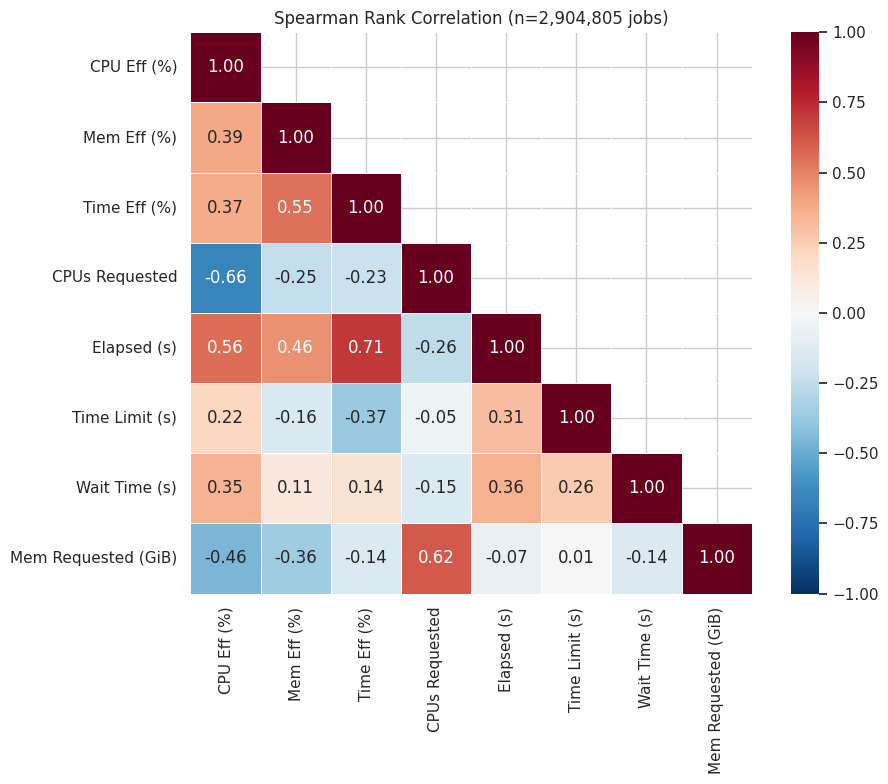

In [14]:
def correlation_heatmap():
    """Spearman correlation heatmap of job-level metrics."""
    if not HAS_JOB_DATA:
        print("Per-job data not available.")
        return

    corr_cols = {
        'cpu_eff_req': 'CPU Eff (%)',
        'mem_eff': 'Mem Eff (%)',
        'time_eff': 'Time Eff (%)',
        'req_cpus': 'CPUs Requested',
        'elapsed_sec': 'Elapsed (s)',
        'timelimit_sec': 'Time Limit (s)',
        'wait_sec': 'Wait Time (s)',
    }

    # Add memory in GiB for readability
    df_corr = df_jobs[list(corr_cols.keys())].copy()
    df_corr['reqmem_gib'] = df_jobs['reqmem_bytes'] / (1024**3)
    corr_cols['reqmem_gib'] = 'Mem Requested (GiB)'

    df_corr = df_corr.rename(columns=corr_cols).dropna()

    corr_matrix = df_corr.corr(method='spearman')

    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, vmin=-1, vmax=1, square=True, ax=ax,
                linewidths=0.5)
    ax.set_title(f'Spearman Rank Correlation (n={len(df_corr):,} jobs)')
    plt.tight_layout()
    plt.show()

correlation_heatmap()

### CPU vs Memory Efficiency

/tmp/ipykernel_737757/1705438933.py:34: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/nadine-spychala/.pyenv/versions/hpc-data-analysis-env/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


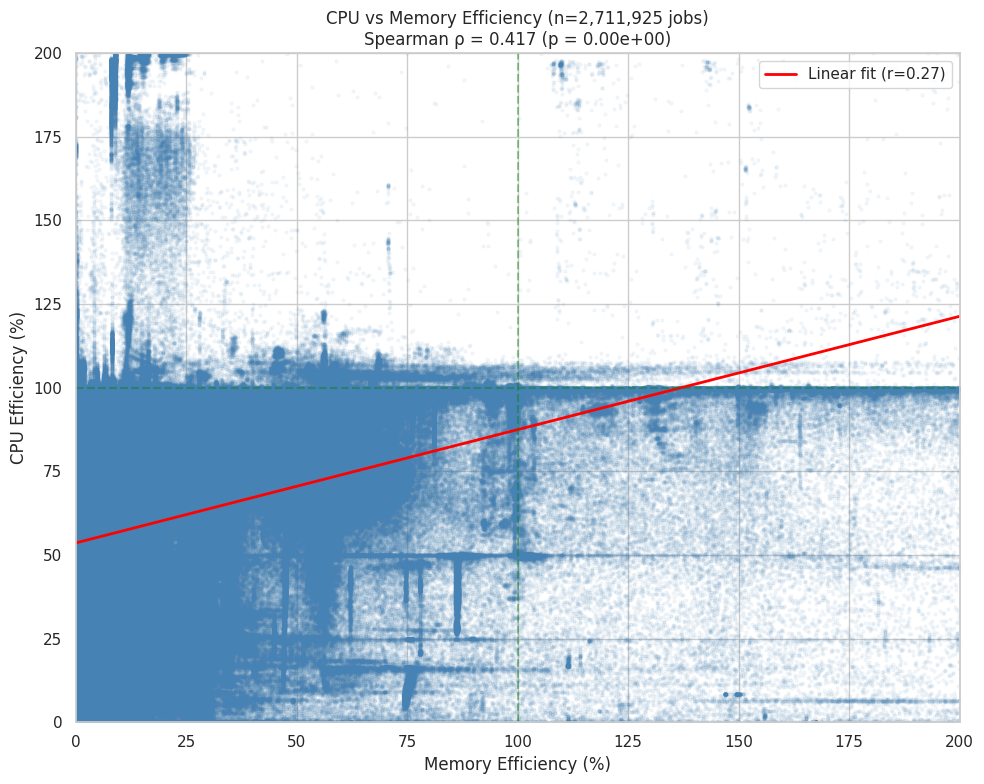

In [15]:
def cpu_vs_memory_scatter():
    """Scatter plot of CPU vs Memory efficiency at job level with regression line."""
    if not HAS_JOB_DATA:
        print("Per-job data not available.")
        return

    plot_data = df_jobs[['cpu_eff_req', 'mem_eff']].dropna()
    # Cap at 200% for readability
    plot_data = plot_data[(plot_data['cpu_eff_req'] <= 200) & (plot_data['mem_eff'] <= 200)]

    # Spearman correlation
    rho, p_value = stats.spearmanr(plot_data['cpu_eff_req'], plot_data['mem_eff'])

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(plot_data['mem_eff'], plot_data['cpu_eff_req'],
               alpha=0.05, s=5, color='steelblue', rasterized=True)

    # Regression line
    slope, intercept, r_value, p_lin, stderr = stats.linregress(
        plot_data['mem_eff'], plot_data['cpu_eff_req'])
    x_line = np.linspace(0, 200, 100)
    ax.plot(x_line, slope * x_line + intercept, color='red', linewidth=2,
            label=f'Linear fit (r={r_value:.2f})')

    ax.axhline(y=100, color='green', linestyle='--', alpha=0.4)
    ax.axvline(x=100, color='green', linestyle='--', alpha=0.4)
    ax.set_xlabel('Memory Efficiency (%)')
    ax.set_ylabel('CPU Efficiency (%)')
    ax.set_title(f'CPU vs Memory Efficiency (n={len(plot_data):,} jobs)\n'
                 f'Spearman \u03c1 = {rho:.3f} (p = {p_value:.2e})')
    ax.set_xlim(0, 200)
    ax.set_ylim(0, 200)
    ax.legend()
    plt.tight_layout()
    plt.show()

cpu_vs_memory_scatter()

## 4.4 Efficiency > 100% Analysis

Jobs with efficiency above 100% indicate either:
- **CPU >100%**: Code uses more threads than CPUs requested (user under-requesting), or Slurm allocates more CPUs than requested due to core-level allocation
- **Memory >100%**: Job used more memory than requested (possible when memory limits weren't enforced)

This section also compares efficiency based on **requested** vs **allocated** CPUs to separate these effects.

In [16]:
def efficiency_over_100_summary():
    """Global summary of jobs with efficiency > 100%."""
    if not HAS_JOB_DATA:
        print("Per-job data not available.")
        return
    
    cpu_req_valid = df_jobs['cpu_eff_req'].notna()
    cpu_req_over_100 = (df_jobs['cpu_eff_req'] > 100).sum()
    cpu_req_over_100_pct = cpu_req_over_100 / cpu_req_valid.sum() * 100
    
    cpu_alloc_valid = df_jobs['cpu_eff_alloc'].notna()
    cpu_alloc_over_100 = (df_jobs['cpu_eff_alloc'] > 100).sum()
    cpu_alloc_over_100_pct = cpu_alloc_over_100 / cpu_alloc_valid.sum() * 100
    
    mem_valid = df_jobs['mem_eff'].notna()
    mem_over_100 = (df_jobs['mem_eff'] > 100).sum()
    mem_over_100_pct = mem_over_100 / mem_valid.sum() * 100
    
    display(Markdown(f"""
### Global Summary

| Metric | Jobs > 100% | % of valid jobs |
|--------|-------------|-----------------|
| **CPU Efficiency (requested)** | {cpu_req_over_100:,} | {cpu_req_over_100_pct:.1f}% |
| **CPU Efficiency (allocated)** | {cpu_alloc_over_100:,} | {cpu_alloc_over_100_pct:.1f}% |
| **Memory Efficiency** | {mem_over_100:,} | {mem_over_100_pct:.1f}% |

*Valid jobs = jobs with non-null efficiency values*
"""))

efficiency_over_100_summary()



### Global Summary

| Metric | Jobs > 100% | % of valid jobs |
|--------|-------------|-----------------|
| **CPU Efficiency (requested)** | 97,342 | 3.4% |
| **CPU Efficiency (allocated)** | 34,420 | 1.2% |
| **Memory Efficiency** | 274,154 | 9.4% |

*Valid jobs = jobs with non-null efficiency values*


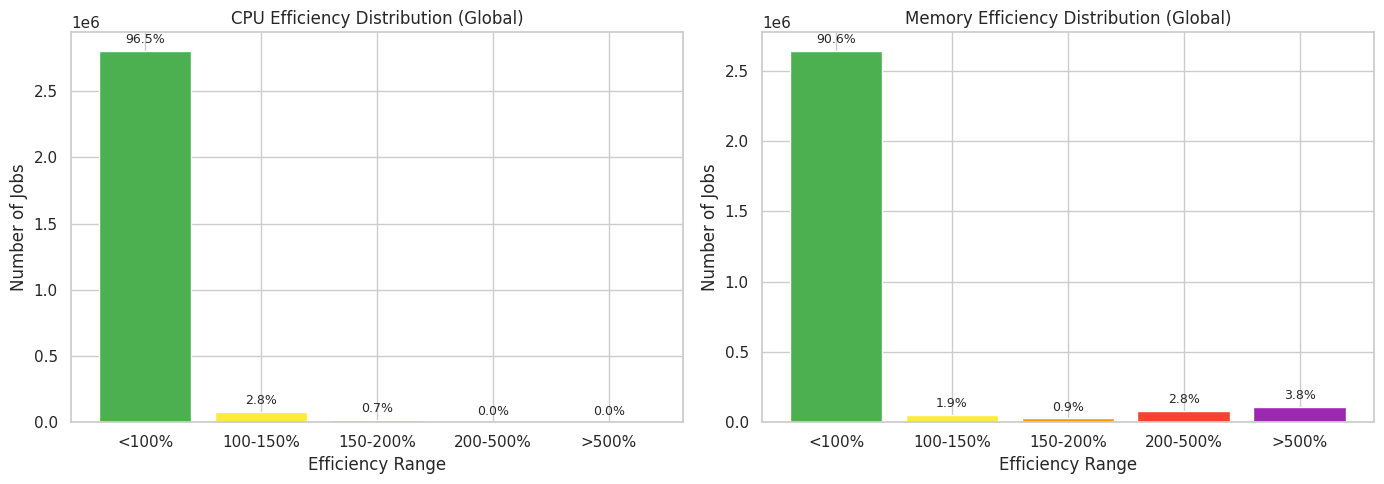

In [17]:
def plot_efficiency_severity_global():
    """Bar plot showing distribution of efficiency by severity bins (global)."""
    if 'df_jobs' not in globals() or df_jobs is None:
        print("Per-job data not available. Run cells above first.")
        return
    
    # Define bins
    bins = [0, 100, 150, 200, 500, float('inf')]
    labels = ['<100%', '100-150%', '150-200%', '200-500%', '>500%']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # CPU efficiency
    cpu_data = df_jobs['cpu_eff_req'].dropna()
    cpu_binned = pd.cut(cpu_data, bins=bins, labels=labels, right=False)
    cpu_counts = cpu_binned.value_counts().reindex(labels, fill_value=0)
    cpu_total = cpu_counts.sum()
    cpu_pcts = (cpu_counts / cpu_total * 100).values
    
    colors = ['#4caf50', '#ffeb3b', '#ff9800', '#f44336', '#9c27b0']
    axes[0].bar(labels, cpu_counts.values, color=colors, edgecolor='white')
    axes[0].set_xlabel('Efficiency Range')
    axes[0].set_ylabel('Number of Jobs')
    axes[0].set_title('CPU Efficiency Distribution (Global)')
    for i, (v, pct) in enumerate(zip(cpu_counts.values, cpu_pcts)):
        if v > 0:
            axes[0].text(i, v + max(cpu_counts.values)*0.02, f'{pct:.1f}%', ha='center', fontsize=9)
    
    # Memory efficiency
    mem_data = df_jobs['mem_eff'].dropna()
    mem_binned = pd.cut(mem_data, bins=bins, labels=labels, right=False)
    mem_counts = mem_binned.value_counts().reindex(labels, fill_value=0)
    mem_total = mem_counts.sum()
    mem_pcts = (mem_counts / mem_total * 100).values
    
    axes[1].bar(labels, mem_counts.values, color=colors, edgecolor='white')
    axes[1].set_xlabel('Efficiency Range')
    axes[1].set_ylabel('Number of Jobs')
    axes[1].set_title('Memory Efficiency Distribution (Global)')
    for i, (v, pct) in enumerate(zip(mem_counts.values, mem_pcts)):
        if v > 0:
            axes[1].text(i, v + max(mem_counts.values)*0.02, f'{pct:.1f}%', ha='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()

plot_efficiency_severity_global()

In [18]:
# CPU Efficiency: Requested vs Allocated CPUs
display(Markdown("""
### CPU Efficiency: Requested vs Allocated

This compares CPU efficiency calculated using:
- **Requested CPUs** (`req_cpus`): What users asked for
- **Allocated CPUs** (`alloc_cpus`): Hardware threads allocated by Slurm

**Cluster configuration:** `SelectTypeParameters = CR_CORE_MEMORY`
- Slurm allocates whole cores, not individual hardware threads
- On hyperthreaded nodes (2 threads per core), requesting 1 CPU allocates 1 core = 2 hardware threads
- `alloc_cpus` stores hardware threads, so it can be 2\u00d7 `req_cpus`

**Why >100% still appears with allocated CPUs:** With `ConstrainCores` enabled, efficiency should theoretically be \u2264100%. The cause of >100% values is not fully understood.
"""))

# Global stats
display(Markdown("#### Global Stats"))
global_df = pd.read_csv(FACULTY_STATS_PATH, comment='#')
global_df = global_df[global_df['faculty'].str.strip('"') == 'all']
if len(global_df) > 0:
    global_comparison = pd.DataFrame({
        'Metric': ['Average CPU Efficiency'],
        'Based on Requested': [f"{global_df['avg_cpu_eff_req'].values[0]:.1f}%"],
        'Based on Allocated': [f"{global_df['avg_cpu_eff_alloc'].values[0]:.1f}%"]
    })
    display(global_comparison)
else:
    print("No global stats found. Run aggregate_stats with --collate_by none to generate.")

# Merged per-faculty table: avg efficiencies + >100% percentages
display(Markdown("#### By Faculty"))
if HAS_JOB_DATA and 'faculty' in df_jobs.columns and 'avg_cpu_eff_alloc' in df_faculties.columns:
    faculty_rows = []
    for faculty in df_faculties.sort_values('job_count', ascending=False)['faculty']:
        fac_agg = df_faculties[df_faculties['faculty'] == faculty].iloc[0]
        fac_jobs = df_jobs[df_jobs['faculty'] == faculty]
        n_jobs = len(fac_jobs)

        cpu_req_valid_n = fac_jobs['cpu_eff_req'].notna().sum()
        cpu_req_over = (fac_jobs['cpu_eff_req'] > 100).sum()
        cpu_req_over_pct = (cpu_req_over / cpu_req_valid_n * 100) if cpu_req_valid_n > 0 else 0

        cpu_alloc_valid_n = fac_jobs['cpu_eff_alloc'].notna().sum()
        cpu_alloc_over = (fac_jobs['cpu_eff_alloc'] > 100).sum()
        cpu_alloc_over_pct = (cpu_alloc_over / cpu_alloc_valid_n * 100) if cpu_alloc_valid_n > 0 else 0

        mem_valid_n = fac_jobs['mem_eff'].notna().sum()
        mem_over = (fac_jobs['mem_eff'] > 100).sum()
        mem_over_pct = (mem_over / mem_valid_n * 100) if mem_valid_n > 0 else 0

        faculty_rows.append({
            'Faculty': faculty,
            'Jobs': n_jobs,
            'Avg CPU Eff (req)': round(float(fac_agg['avg_cpu_eff_req']), 2),
            'Avg CPU Eff (alloc)': round(float(fac_agg['avg_cpu_eff_alloc']), 2),
            'CPU Req >100%': f"{cpu_req_over_pct:.1f}%",
            'CPU Alloc >100%': f"{cpu_alloc_over_pct:.1f}%",
            'Mem >100%': f"{mem_over_pct:.1f}%",
        })

    merged_df = pd.DataFrame(faculty_rows)
    display(merged_df.style.hide(axis='index').format({
        'Avg CPU Eff (req)': '{:.2f}',
        'Avg CPU Eff (alloc)': '{:.2f}',
    }))
else:
    cols_to_show = ['faculty', 'job_count', 'avg_cpu_eff_req', 'avg_cpu_eff_alloc']
    cols_available = [c for c in cols_to_show if c in df_faculties.columns]
    display(df_faculties[cols_available].sort_values('job_count', ascending=False).round(1))



### CPU Efficiency: Requested vs Allocated

This compares CPU efficiency calculated using:
- **Requested CPUs** (`req_cpus`): What users asked for
- **Allocated CPUs** (`alloc_cpus`): Hardware threads allocated by Slurm

**Cluster configuration:** `SelectTypeParameters = CR_CORE_MEMORY`
- Slurm allocates whole cores, not individual hardware threads
- On hyperthreaded nodes (2 threads per core), requesting 1 CPU allocates 1 core = 2 hardware threads
- `alloc_cpus` stores hardware threads, so it can be 2× `req_cpus`

**Why >100% still appears with allocated CPUs:** With `ConstrainCores` enabled, efficiency should theoretically be ≤100%. The cause of >100% values is not fully understood.


#### Global Stats

,Metric,Based on Requested,Based on Allocated
0,Average CPU Efficiency,62.0%,59.2%


#### By Faculty

Faculty,Jobs,Avg CPU Eff (req),Avg CPU Eff (alloc),CPU Req >100%,CPU Alloc >100%,Mem >100%
"Faculty of Natural, Mathematical & Engineering Sciences",1158387,78.33,76.17,2.3%,1.7%,10.5%
"Institute of Psychiatry, Psychology & Neuroscience",1008301,46.47,44.22,2.8%,1.0%,6.6%
"Faculty of Dentistry, Oral & Craniofacial Sciences",299032,63.39,57.29,7.2%,0.5%,17.5%
Faculty of Life Sciences & Medicine,339500,58.74,53.91,5.3%,0.2%,8.7%
Faculty of Social Science & Public Policy,56472,83.76,83.57,4.1%,4.0%,5.0%
King's Business School,36827,0.59,0.59,0.0%,0.0%,0.3%
unknown,16657,37.47,24.39,5.2%,0.1%,9.7%
Research Management & Innovation,442,24.80,23.60,1.4%,0.2%,16.3%
Faculty of Arts & Humanities,262,37.73,23.78,5.9%,0.0%,56.9%
Other,152,77.18,77.18,2.7%,2.7%,11.8%


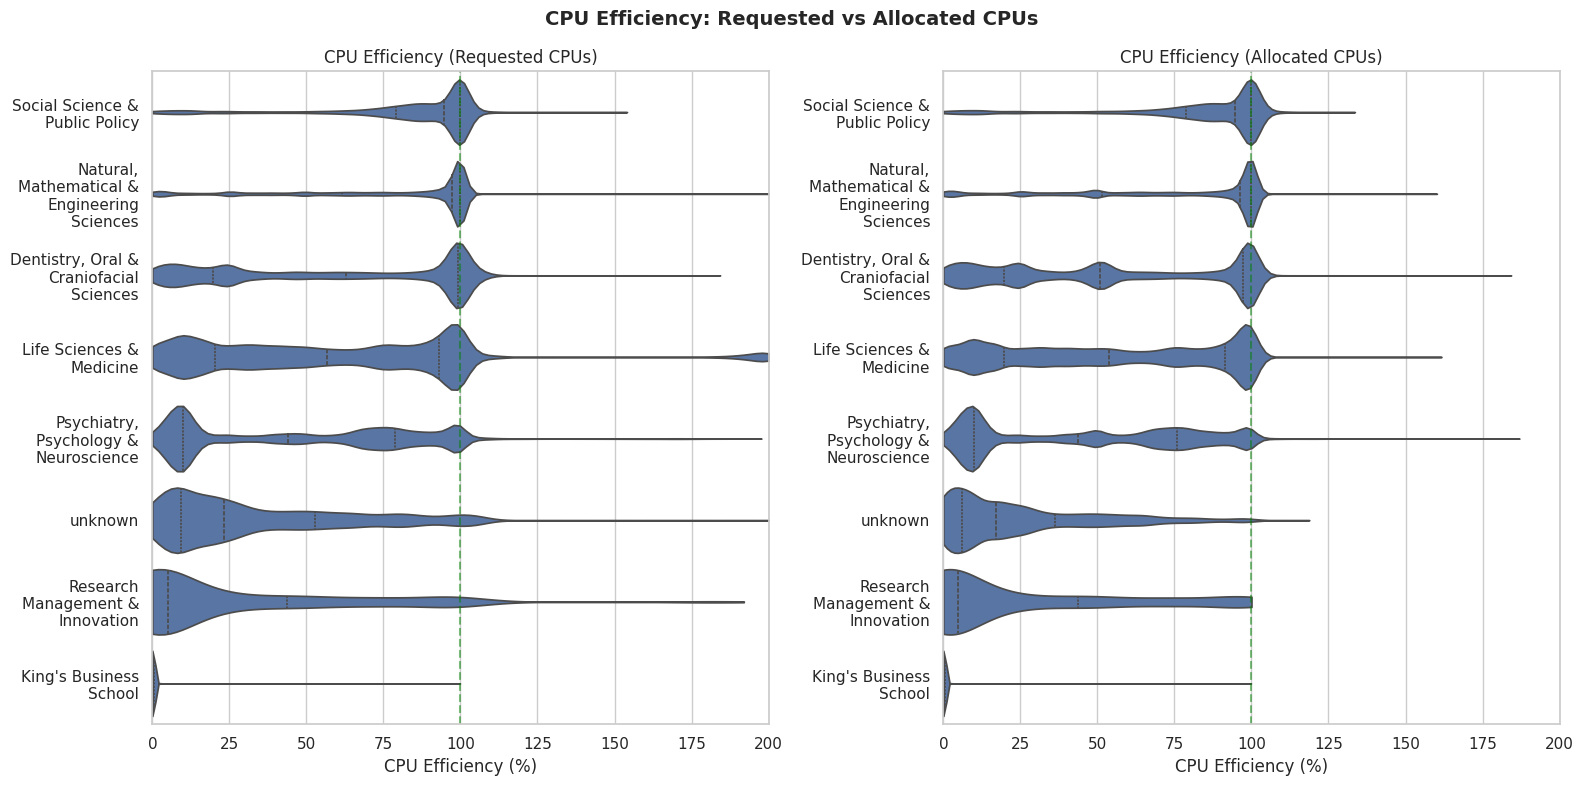


| Metric | Jobs > 100% | Total valid | % > 100% |
|--------|-------------|-------------|----------|
| **Requested CPUs** | 97,342 | 2,904,805 | 3.4% |
| **Allocated CPUs** | 34,420 | 2,905,079 | 1.2% |



**Interpretation:**
- **Left (Requested)**: Can exceed 100% because Slurm allocates whole cores (`CR_CORE_MEMORY`). Requesting 1 CPU allocates 1 core = 2 hardware threads on hyperthreaded nodes. `alloc_cpus` stores hardware threads, so `alloc_cpus` can be 2× `req_cpus`.
- **Right (Allocated)**: Shows efficiency using allocated hardware threads. With `ConstrainCores` enabled, this should theoretically be ≤100%.
- **Why >100% still appears with allocated CPUs**: The cause is not fully understood. Possibly related to multi-node job accounting or other Slurm configs.


In [19]:
# Violin plot: CPU Efficiency based on Allocated CPUs
def plot_violin_cpu_eff_alloc():
    """Compare CPU efficiency distributions: requested vs allocated."""
    if not HAS_JOB_DATA:
        print("Per-job data not available.")
        return

    if 'cpu_eff_alloc' not in df_jobs.columns:
        print("cpu_eff_alloc column not found in job data.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    plot_data = df_jobs[df_jobs['cpu_eff_req'].notna() & (df_jobs['cpu_eff_req'] <= 200)].copy()
    top_faculties = plot_data['faculty'].value_counts().head(8).index.tolist()
    plot_data = plot_data[plot_data['faculty'].isin(top_faculties)]

    # Order by avg CPU efficiency
    ranking = (df_faculties[df_faculties['faculty'].isin(top_faculties)]
               .sort_values(CPU_EFF_COL, ascending=False))
    order = [FACULTY_SHORT.get(f, f) for f in ranking['faculty']]

    # Left: based on requested CPUs
    sns.violinplot(data=plot_data, y='faculty_short', x='cpu_eff_req', ax=axes[0],
                   cut=0, order=order, density_norm='width', inner='quartile')
    axes[0].axvline(x=100, color='green', linestyle='--', alpha=0.5)
    axes[0].set_xlabel('CPU Efficiency (%)')
    axes[0].set_ylabel('')
    axes[0].set_title('CPU Efficiency (Requested CPUs)')
    axes[0].set_xlim(0, 200)

    # Right: based on allocated CPUs
    plot_data_alloc = df_jobs[df_jobs['cpu_eff_alloc'].notna() & (df_jobs['cpu_eff_alloc'] <= 200)].copy()
    plot_data_alloc = plot_data_alloc[plot_data_alloc['faculty'].isin(top_faculties)]

    sns.violinplot(data=plot_data_alloc, y='faculty_short', x='cpu_eff_alloc', ax=axes[1],
                   cut=0, order=order, density_norm='width', inner='quartile')
    axes[1].axvline(x=100, color='green', linestyle='--', alpha=0.5)
    axes[1].set_xlabel('CPU Efficiency (%)')
    axes[1].set_ylabel('')
    axes[1].set_title('CPU Efficiency (Allocated CPUs)')
    axes[1].set_xlim(0, 200)

    plt.suptitle('CPU Efficiency: Requested vs Allocated CPUs', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Summary: >100% counts
    req_valid = df_jobs['cpu_eff_req'].notna().sum()
    req_over = (df_jobs['cpu_eff_req'] > 100).sum()
    alloc_valid = df_jobs['cpu_eff_alloc'].notna().sum()
    alloc_over = (df_jobs['cpu_eff_alloc'] > 100).sum()

    display(Markdown(f"""
| Metric | Jobs > 100% | Total valid | % > 100% |
|--------|-------------|-------------|----------|
| **Requested CPUs** | {req_over:,} | {req_valid:,} | {req_over/req_valid*100:.1f}% |
| **Allocated CPUs** | {alloc_over:,} | {alloc_valid:,} | {alloc_over/alloc_valid*100:.1f}% |
"""))

    display(Markdown("""
**Interpretation:**
- **Left (Requested)**: Can exceed 100% because Slurm allocates whole cores (`CR_CORE_MEMORY`). Requesting 1 CPU allocates 1 core = 2 hardware threads on hyperthreaded nodes. `alloc_cpus` stores hardware threads, so `alloc_cpus` can be 2\u00d7 `req_cpus`.
- **Right (Allocated)**: Shows efficiency using allocated hardware threads. With `ConstrainCores` enabled, this should theoretically be \u2264100%.
- **Why >100% still appears with allocated CPUs**: The cause is not fully understood. Possibly related to multi-node job accounting or other Slurm configs.
"""))

plot_violin_cpu_eff_alloc()


### Memory Efficiency: Requested vs Allocated

The same requested-vs-allocated discrepancy applies to **memory** for `--mem-per-cpu` jobs:
- **Requested memory** (`tres_req`): what the user asked for
- **Allocated memory** (`tres_alloc`): what Slurm actually reserved

For `--mem-per-cpu` jobs, Slurm allocates memory proportional to `alloc_cpus`, not `cpus_req`. When `alloc_cpus > cpus_req` (due to core-level allocation on hyperthreaded nodes), the allocated memory exceeds the requested memory.

With `ConstrainRAMSpace` enabled, the cgroup enforces the **allocated** amount, so jobs can legally use more memory than they requested.

In [ ]:
# Violin plot: Memory Efficiency based on Requested vs Allocated Memory
def plot_violin_mem_eff_alloc():
    """Compare memory efficiency distributions: requested vs allocated memory."""
    if not HAS_JOB_DATA:
        print("Per-job data not available.")
        return

    if 'mem_eff_alloc' not in df_jobs.columns:
        print("mem_eff_alloc column not found in job data. Re-run job_stats with updated pipeline.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    top_faculties = df_jobs['faculty'].value_counts().head(8).index.tolist()

    # Order by avg memory efficiency
    ranking = (df_faculties[df_faculties['faculty'].isin(top_faculties)]
               .sort_values(MEM_EFF_COL, ascending=False))
    order = [FACULTY_SHORT.get(f, f) for f in ranking['faculty']]

    # Left: based on requested memory
    plot_data_req = df_jobs[df_jobs['mem_eff'].notna() & (df_jobs['mem_eff'] <= 200)].copy()
    plot_data_req = plot_data_req[plot_data_req['faculty'].isin(top_faculties)]

    sns.violinplot(data=plot_data_req, y='faculty_short', x='mem_eff', ax=axes[0],
                   cut=0, order=order, density_norm='width', inner='quartile')
    axes[0].axvline(x=100, color='green', linestyle='--', alpha=0.5)
    axes[0].set_xlabel('Memory Efficiency (%)')
    axes[0].set_ylabel('')
    axes[0].set_title('Memory Efficiency (Requested Memory)')
    axes[0].set_xlim(0, 200)

    # Right: based on allocated memory
    plot_data_alloc = df_jobs[df_jobs['mem_eff_alloc'].notna() & (df_jobs['mem_eff_alloc'] <= 200)].copy()
    plot_data_alloc = plot_data_alloc[plot_data_alloc['faculty'].isin(top_faculties)]

    sns.violinplot(data=plot_data_alloc, y='faculty_short', x='mem_eff_alloc', ax=axes[1],
                   cut=0, order=order, density_norm='width', inner='quartile')
    axes[1].axvline(x=100, color='green', linestyle='--', alpha=0.5)
    axes[1].set_xlabel('Memory Efficiency (%)')
    axes[1].set_ylabel('')
    axes[1].set_title('Memory Efficiency (Allocated Memory)')
    axes[1].set_xlim(0, 200)

    plt.suptitle('Memory Efficiency: Requested vs Allocated Memory', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Summary: >100% counts
    req_valid = df_jobs['mem_eff'].notna().sum()
    req_over = (df_jobs['mem_eff'] > 100).sum()
    alloc_valid = df_jobs['mem_eff_alloc'].notna().sum()
    alloc_over = (df_jobs['mem_eff_alloc'] > 100).sum()

    display(Markdown(f"""
| Metric | Jobs > 100% | Total valid | % > 100% |
|--------|-------------|-------------|----------|
| **Requested Memory** | {req_over:,} | {req_valid:,} | {req_over/req_valid*100:.1f}% |
| **Allocated Memory** | {alloc_over:,} | {alloc_valid:,} | {alloc_over/alloc_valid*100:.1f}% |
"""))

    display(Markdown("""
**Interpretation:**
- **Left (Requested)**: Can exceed 100% because for `--mem-per-cpu` jobs, Slurm allocates more memory when `alloc_cpus > cpus_req` due to core-level allocation.
- **Right (Allocated)**: Shows efficiency against the memory actually enforced by the cgroup. This should be a more accurate picture of memory usage.
"""))

plot_violin_mem_eff_alloc()

In [ ]:
# Violin plot: Memory Efficiency (Allocated) by Memory Request Type
def plot_violin_mem_eff_by_type():
    """Compare mem_eff_alloc distributions: --mem (per-node) vs --mem-per-cpu."""
    if not HAS_JOB_DATA:
        print("Per-job data not available.")
        return

    if 'mem_eff_alloc' not in df_jobs.columns or 'mem_type' not in df_jobs.columns:
        print("mem_eff_alloc or mem_type column not found. Re-run job_stats with updated pipeline.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    top_faculties = df_jobs['faculty'].value_counts().head(8).index.tolist()

    # Order by avg memory efficiency
    ranking = (df_faculties[df_faculties['faculty'].isin(top_faculties)]
               .sort_values(MEM_EFF_COL, ascending=False))
    order = [FACULTY_SHORT.get(f, f) for f in ranking['faculty']]

    # Left: --mem (per-node) jobs only
    pernode_data = df_jobs[(df_jobs['mem_type'] == 'per-node') &
                           df_jobs['mem_eff_alloc'].notna() &
                           (df_jobs['mem_eff_alloc'] <= 200)].copy()
    pernode_data = pernode_data[pernode_data['faculty'].isin(top_faculties)]

    if len(pernode_data) > 0:
        sns.violinplot(data=pernode_data, y='faculty_short', x='mem_eff_alloc', ax=axes[0],
                       cut=0, order=order, density_norm='width', inner='quartile')
    axes[0].axvline(x=100, color='green', linestyle='--', alpha=0.5)
    axes[0].set_xlabel('Memory Efficiency (%)')
    axes[0].set_ylabel('')
    axes[0].set_title(f'--mem (per-node) jobs (n={len(pernode_data):,})')
    axes[0].set_xlim(0, 200)

    # Right: --mem-per-cpu jobs only
    percpu_data = df_jobs[(df_jobs['mem_type'] == 'per-cpu') &
                          df_jobs['mem_eff_alloc'].notna() &
                          (df_jobs['mem_eff_alloc'] <= 200)].copy()
    percpu_data = percpu_data[percpu_data['faculty'].isin(top_faculties)]

    if len(percpu_data) > 0:
        sns.violinplot(data=percpu_data, y='faculty_short', x='mem_eff_alloc', ax=axes[1],
                       cut=0, order=order, density_norm='width', inner='quartile')
    axes[1].axvline(x=100, color='green', linestyle='--', alpha=0.5)
    axes[1].set_xlabel('Memory Efficiency (%)')
    axes[1].set_ylabel('')
    axes[1].set_title(f'--mem-per-cpu jobs (n={len(percpu_data):,})')
    axes[1].set_xlim(0, 200)

    plt.suptitle('Memory Efficiency (Allocated) by Memory Request Type', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Summary table: >100% by memory type, requested vs allocated
    rows = []
    for mem_type_label, mem_type_val in [('--mem (per-node)', 'per-node'), ('--mem-per-cpu', 'per-cpu')]:
        subset = df_jobs[df_jobs['mem_type'] == mem_type_val] if 'mem_type' in df_jobs.columns else df_jobs
        n_total = len(subset)

        req_valid = subset['mem_eff'].notna().sum()
        req_over = (subset['mem_eff'] > 100).sum()
        req_pct = (req_over / req_valid * 100) if req_valid > 0 else 0

        alloc_valid = subset['mem_eff_alloc'].notna().sum()
        alloc_over = (subset['mem_eff_alloc'] > 100).sum()
        alloc_pct = (alloc_over / alloc_valid * 100) if alloc_valid > 0 else 0

        rows.append({
            'Memory Type': mem_type_label,
            'Total Jobs': f"{n_total:,}",
            'Req >100%': f"{req_over:,} ({req_pct:.1f}%)",
            'Alloc >100%': f"{alloc_over:,} ({alloc_pct:.1f}%)",
        })

    display(Markdown("#### Summary: Jobs with Memory Efficiency > 100% by Type"))
    display(pd.DataFrame(rows).style.hide(axis='index'))

    display(Markdown("""
**Interpretation:**
- If the >100% issue is specific to `--mem-per-cpu` jobs (as hypothesised), the left panel should show fewer >100% jobs when using allocated memory.
- The right panel (`--mem-per-cpu`) is where `alloc_mem > req_mem` occurs, so the gap between requested and allocated efficiency should be largest here.
"""))

plot_violin_mem_eff_by_type()

---
# 5. Why Efficiency Matters

## The Problem: Resource Waste

When you request resources (CPUs, memory) for your job, those resources are **reserved exclusively for you**, even if you don't use them. This means:

- Other users can't run their jobs while your resources sit idle
- Queue wait times increase for everyone
- The cluster appears "full" when it's actually underutilised

## What "Good" Efficiency Looks Like

| Range | Rating | Meaning |
|-------|--------|---------||
| 70–100% | Excellent | You're using what you requested |
| 30–70% | Acceptable | Room for improvement |
| <30% | Poor | Significant waste — please optimise |

## How to Improve Your Efficiency

1. **Profile your jobs first** — Run a small test job and check actual resource usage with `seff <jobid>`
2. **Request what you need (plus 10–20% buffer)** — If your test used 8 GB, request 10 GB, not 64 GB
3. **Use job arrays for many small jobs** — Instead of requesting 100 CPUs for one job, submit 100 single-CPU jobs
4. **Check your code's parallelisation** — If you request 16 CPUs but your code only uses 1, you're wasting 15 CPUs

---
# 6. Technical Appendix

## Data Sources

- **Job data:** Slurm accounting database (MySQL), accessed directly via `mysql.connector` (not via `sacct`, for reliability).
  - `create_job_table`: job metadata — timestamps, resource requests (`cpus_req`, `tres_req`), state, time limit
  - `create_step_table`: per-step CPU time (`user_sec`, `sys_sec`) and peak memory usage (`tres_usage_in_max`)
  - `create_assoc_table`: maps job associations to usernames
- **Faculty mapping:** Active Directory via LDAP. Each username is looked up to retrieve its faculty attribute (`st`).

## Efficiency Metrics

### Average vs Weighted

This notebook uses **average efficiency** — the mean of per-job efficiency values. Each job counts equally, regardless of size.

| Version | Formula | Question it answers |
|---------|---------|---------------------|
| **Average** | Mean(per-job efficiency) | "What's the typical job's efficiency?" Each job counts equally. |
| **Weighted** | Sum(used) / Sum(allocated) × 100 | "How efficiently are allocated resources being used overall?" Larger jobs contribute more. |

For infrastructure planning (where large jobs matter more), see `visualisation_infrastructure.ipynb`.

### CPU Efficiency

`CPU Efficiency = TotalCPU / (Elapsed × CPUs) × 100`

- **TotalCPU** = user-mode CPU seconds + system-mode CPU seconds + microsecond fractions.
- **CPUs** = either `cpus_req` (requested) or `alloc_cpus` (allocated) from the job table.

**Why efficiency based on requested CPUs can exceed 100%:** We cannot distinguish between these two causes:
- **Allocation granularity**: Slurm allocates more CPUs than requested due to core-level allocation
- **User behavior**: Code uses more threads than requested

**Requested vs allocated CPUs:** The cluster uses `CR_CORE_MEMORY` allocation (`SelectTypeParameters`), meaning Slurm allocates whole cores. On hyperthreaded nodes (2 threads per core), requesting 1 CPU allocates 1 core = 2 hardware threads. The `alloc_cpus` field stores hardware threads, so `alloc_cpus` can be 2× `req_cpus`.

**Why efficiency based on allocated CPUs can still exceed 100%:** With `ConstrainCores` enabled, jobs are restricted to their allocated cores, so efficiency should theoretically be ≤100%. The cause of >100% values is not fully understood — possibly related to multi-node job accounting or other Slurm internals.

### Memory Efficiency

`Memory Efficiency = MaxRSS / ReqMem × 100`

- **MaxRSS**: Peak memory usage across all steps.
- **ReqMem**: Requested memory (always stored as total memory regardless of how it was requested).

**Why it can exceed 100%:** The data in this analysis is from a period when memory limits were **not enforced** (`ConstrainRAMSpace` was disabled). Jobs could exceed requested memory without being killed. Memory enforcement has since been enabled — new jobs exceeding their memory request will be terminated.

### Time Efficiency

`Time Efficiency = Elapsed / (Timelimit × 60) × 100`

Measures what fraction of the requested wall-clock time was actually used.

## Resource Enforcement (cgroups)

Slurm can enforce resource limits using Linux cgroups:

| Resource | Setting | Status | Effect |
|----------|---------|--------|--------|
| Memory | `ConstrainRAMSpace` | Now enabled | Jobs killed if exceeding request |
| CPU | `ConstrainCores` | Enabled | Jobs restricted to allocated cores |

With `ConstrainCores` enabled, jobs are restricted to their allocated cores.

## Job States Included

Only jobs in specific terminal states are included:

| State | Included | Why |
|-------|----------|-----|
| COMPLETED | **Yes** | Clean efficiency data |
| TIMEOUT | **Yes** | Job ran its full requested time |
| OUT_OF_MEMORY | **Yes** | Shows memory under-requesting |
| CANCELLED, FAILED, NODE_FAIL, PREEMPTED | No | Incomplete, potentially misleading |

**Success/Failure Metrics:** Computed across ALL job states:
- Success = COMPLETED only
- Failed = FAILED, TIMEOUT, NODE_FAIL, PREEMPTED, OUT_OF_MEMORY
- CANCELLED is excluded from failure count (intentional user action)

**Efficiency Metrics:** Only computed for COMPLETED, TIMEOUT, and OUT_OF_MEMORY jobs (which ran long enough to have meaningful resource usage data).

## Limitations and Future Work

### Cannot distinguish allocation granularity from user behavior

When CPU efficiency exceeds 100% based on requested CPUs, we cannot tell whether this is due to:
1. Slurm allocating more CPUs than requested (allocation granularity)
2. Users running multi-threaded code while requesting fewer CPUs

**Why not?** The Slurm accounting database stores `cpus_req` (total CPUs requested) but does not store the `--ntasks` submission parameter directly. The `n_tasks` field in our data comes from `task_cnt` in the step table, which is the number of tasks *per step*, not the job submission parameter.

**Future analysis option:** The `submit_line` column in both `create_job_table` and `create_step_table` contains the raw submission command. Parsing this could reveal what flags users actually used (e.g., `--ntasks=8` vs `--cpus-per-task=8`), but this would require text parsing and is not currently implemented.

In [20]:
display(Markdown("### Raw Faculty Data"))
display(df_faculties)

### Raw Faculty Data

,faculty,job_count,job_count_success,job_count_failed,count_timeout,count_out_of_memory,total_elapsed_sec,total_cpu_sec,total_user_cpu_sec,total_sys_cpu_sec,...,avg_reqcpus,avg_wait_sec,weighted_cpu_eff_req,weighted_mem_eff,weighted_time_eff,avg_cpu_eff_req,avg_cpu_eff_alloc,avg_mem_eff,avg_time_eff,faculty_short
0,Faculty of Arts & Humanities,581,228,219,34,0,1.561950e+06,1.513209e+06,1.473781e+06,3.942869e+04,...,1.103270,1429.115318,34.010000,383.529994,12.510000,37.730000,23.780000,3342.920000,28.060000,Arts & Humanities
1,"Faculty of Dentistry, Oral & Craniofacial Scie...",524149,296721,42283,2311,0,1.745397e+09,2.500736e+09,2.245187e+09,2.555494e+08,...,2.313531,1159.123881,41.703518,96.661146,10.382499,63.391350,57.288908,246.115605,9.316611,"Dentistry, Oral &\nCraniofacial\nSciences"
2,Faculty of Life Sciences & Medicine,475915,327845,123984,11655,0,1.253543e+09,1.998303e+09,1.811071e+09,1.872319e+08,...,3.156801,17110.648675,25.321650,13.248632,NaN,58.739043,53.909323,101.968824,9.603983,Life Sciences &\nMedicine
3,"Faculty of Natural, Mathematical & Engineering...",1455312,1106368,239207,52019,0,1.130480e+10,2.977008e+10,2.892777e+10,8.423072e+08,...,6.671683,29908.328486,61.540000,27.112021,NaN,78.330000,76.170000,166.190000,23.390000,"Natural,\nMathematical &\nEngineering\nSciences"
4,Faculty of Social Science & Public Policy,82523,52038,26366,4434,0,1.686906e+09,1.689090e+09,1.682088e+09,7.002143e+06,...,0.919295,23745.807799,95.535478,19.599430,18.651273,83.758302,83.573826,31.561757,18.320539,Social Science &\nPublic Policy
5,IT,45,3,30,22,0,3.944315e+06,2.765349e+06,1.533785e+06,1.231564e+06,...,1.911111,43836.866667,34.410000,57.118414,93.170000,18.110000,11.340000,54.650000,93.300000,IT
6,"Institute of Psychiatry, Psychology & Neurosci...",1095733,998442,69688,9859,0,1.020551e+09,3.939684e+09,3.585451e+09,3.542322e+08,...,4.468009,1862.919600,33.822332,29.704223,0.020987,46.469643,44.222982,108.419134,7.425892,"Psychiatry,\nPsychology &\nNeuroscience"
7,King's Business School,41032,36692,4157,135,0,8.523687e+06,4.559933e+07,4.372911e+07,1.870220e+06,...,80.389915,26186.085909,8.480000,0.017924,0.230000,0.590000,0.590000,1.160000,0.570000,King's Business\nSchool
8,Other,298,152,112,0,0,1.281890e+05,1.240845e+05,1.092242e+05,1.486025e+04,...,0.510067,6.590604,96.800000,11.415547,0.940000,77.180000,77.180000,79.520000,1.400000,Other
9,Research Management & Innovation,798,364,265,78,0,1.107658e+06,7.156932e+04,6.521690e+04,6.352420e+03,...,2.273183,416.276942,0.810000,27.169768,NaN,24.800000,23.600000,98.150000,25.500000,Research\nManagement &\nInnovation


## Aggregate Stats Column Reference

| Column | Description |
|--------|-------------|
| `faculty` | Faculty name (from LDAP lookup) |
| `job_count` | Total jobs submitted (all states) |
| `job_count_success` | Jobs that completed successfully (COMPLETED state only) |
| `job_count_failed` | Jobs that failed (FAILED, TIMEOUT, NODE_FAIL, PREEMPTED, OUT_OF_MEMORY) |
| `count_timeout` | Jobs that hit their time limit |
| `count_out_of_memory` | Jobs killed for exceeding memory |
| `count_interactive` | Jobs detected as interactive (via `--pty` in submit_line) |
| `count_with_ntasks` | Jobs where `--ntasks` was parsed from submit_line |
| `count_with_cpus_per_task` | Jobs where `--cpus-per-task` was parsed from submit_line |
| `total_elapsed_sec` | Sum of wall-clock time across efficiency jobs |
| `avg_elapsed_sec` | Mean wall-clock time per efficiency job |
| `total_cpu_sec` | Sum of CPU time (user + system) across efficiency jobs |
| `avg_cpu_sec` | Mean CPU time per efficiency job |
| `total_user_cpu_sec` | CPU time in user mode (application code) |
| `total_sys_cpu_sec` | CPU time in system mode (kernel/OS operations) |
| `user_cpu_pct` | Percentage of CPU time in user mode |
| `sys_cpu_pct` | Percentage of CPU time in system mode |
| `total_maxrss_bytes` | Sum of peak memory usage |
| `avg_maxrss_bytes` | Mean peak memory usage per job |
| `total_reqmem_bytes` | Sum of requested memory |
| `avg_reqmem_bytes` | Mean requested memory per job |
| `total_reqcpus` | Sum of requested CPUs |
| `avg_reqcpus` | Mean requested CPUs per job |
| `total_nodes` | Sum of nodes used |
| `total_wait_sec` | Sum of queue wait time |
| `avg_wait_sec` | Mean queue wait time per job |
| `weighted_cpu_eff_req` | CPU efficiency based on requested CPUs: total_cpu / (elapsed × req_cpus) |
| `avg_cpu_eff_req` | Mean of per-job CPU efficiency (requested) |
| `weighted_cpu_eff_alloc` | CPU efficiency based on allocated CPUs |
| `avg_cpu_eff_alloc` | Mean of per-job CPU efficiency (allocated) |
| `weighted_mem_eff` | Memory efficiency: total_maxrss / total_reqmem |
| `avg_mem_eff` | Mean of per-job memory efficiency |
| `weighted_time_eff` | Time efficiency: total_elapsed / total_timelimit |
| `avg_time_eff` | Mean of per-job time efficiency |

*Note: Resource totals/averages and efficiency metrics are computed from efficiency jobs only (COMPLETED + TIMEOUT + OUT_OF_MEMORY).*

In [21]:
if HAS_JOB_DATA:
    display(Markdown("### Sample Job-Level Data"))
    display(Markdown(f"Showing first 10 rows of {len(df_jobs):,} jobs:"))
    display(df_jobs.drop(columns=['username']).head(10))

### Sample Job-Level Data

Showing first 10 rows of 2,916,254 jobs:

,job_id,faculty,submission_type,step_count,state,exit_code,is_success,elapsed_sec,wait_sec,timelimit_sec,...,maxrss_bytes,reqmem_bytes,req_cpus,alloc_cpus,n_nodes,n_tasks,submit_line_ntasks,submit_line_cpus_per_task,submit_line_interactive,faculty_short
0,27173887,"Faculty of Natural, Mathematical & Engineering...",batch,1,6,0,0,86425.0,25027.0,86400,...,134909952,34359738368,1,2,1,1,NaN,NaN,0,"Natural,\nMathematical &\nEngineering\nSciences"
1,27173890,"Institute of Psychiatry, Psychology & Neurosci...",batch,1,3,0,1,1.0,62.0,36000,...,319488,8388608000,8,8,1,1,NaN,NaN,0,"Psychiatry,\nPsychology &\nNeuroscience"
2,27173894,"Institute of Psychiatry, Psychology & Neurosci...",batch,1,3,0,1,1.0,61.0,36000,...,409600,8388608000,8,8,1,1,NaN,NaN,0,"Psychiatry,\nPsychology &\nNeuroscience"
3,27173897,"Institute of Psychiatry, Psychology & Neurosci...",batch,1,3,0,1,1.0,61.0,36000,...,217088,8388608000,8,8,1,1,NaN,NaN,0,"Psychiatry,\nPsychology &\nNeuroscience"
4,27173898,"Institute of Psychiatry, Psychology & Neurosci...",batch,1,3,0,1,1.0,60.0,36000,...,405504,8388608000,8,8,1,1,NaN,NaN,0,"Psychiatry,\nPsychology &\nNeuroscience"
5,27173899,"Institute of Psychiatry, Psychology & Neurosci...",batch,1,3,0,1,1.0,60.0,36000,...,360448,8388608000,8,8,1,1,NaN,NaN,0,"Psychiatry,\nPsychology &\nNeuroscience"
6,27173900,"Institute of Psychiatry, Psychology & Neurosci...",batch,1,3,0,1,1.0,61.0,36000,...,188416,8388608000,8,8,1,1,NaN,NaN,0,"Psychiatry,\nPsychology &\nNeuroscience"
7,27173901,"Institute of Psychiatry, Psychology & Neurosci...",batch,1,3,0,1,2.0,71.0,36000,...,389120,8388608000,8,8,1,1,NaN,NaN,0,"Psychiatry,\nPsychology &\nNeuroscience"
8,27173904,"Institute of Psychiatry, Psychology & Neurosci...",batch,1,3,0,1,1.0,71.0,36000,...,311296,8388608000,8,8,1,1,NaN,NaN,0,"Psychiatry,\nPsychology &\nNeuroscience"
9,27173905,"Institute of Psychiatry, Psychology & Neurosci...",batch,1,3,0,1,1.0,60.0,36000,...,94208,8388608000,8,8,1,1,NaN,NaN,0,"Psychiatry,\nPsychology &\nNeuroscience"


## Job-Level Column Reference

| Column | Description |
|--------|-------------|
| `job_id` | Slurm job ID |
| `username` | User who submitted the job |
| `faculty` | Faculty (if `--include-faculty` used) |
| `submission_type` | How job was submitted: batch, interactive, or unknown |
| `step_count` | Number of job steps |
| `state` | Slurm state code (3=COMPLETED, 6=TIMEOUT, 11=OUT_OF_MEMORY) |
| `exit_code` | Exit code from the job |
| `is_success` | 1 if COMPLETED, 0 otherwise |
| `elapsed_sec` | Wall-clock runtime in seconds |
| `wait_sec` | Queue wait time in seconds |
| `timelimit_sec` | Requested time limit in seconds |
| `cpu_eff_req` | CPU efficiency based on requested CPUs (%) |
| `cpu_eff_alloc` | CPU efficiency based on allocated CPUs (%) |
| `mem_eff` | Memory efficiency (%) |
| `time_eff` | Time efficiency: elapsed / timelimit (%) |
| `total_cpu_sec` | Total CPU time (user + system) |
| `user_cpu_sec` | CPU time in user mode |
| `sys_cpu_sec` | CPU time in system mode |
| `user_cpu_pct` | Percentage of CPU time in user mode |
| `maxrss_bytes` | Peak memory usage (bytes) |
| `reqmem_bytes` | Requested memory (bytes) |
| `req_cpus` | Number of CPUs requested (from `tres_req` or `cpus_req` column) |
| `alloc_cpus` | Number of CPUs (hardware threads) allocated by Slurm |
| `n_nodes` | Number of nodes used |
| `n_tasks` | Task count from step table (`task_cnt`). **Note:** This is tasks per step, not the `--ntasks` submission parameter. |
| `submit_line_ntasks` | `--ntasks` value parsed from the raw submit command (NULL if not specified) |
| `submit_line_cpus_per_task` | `--cpus-per-task` value parsed from the raw submit command (NULL if not specified) |
| `submit_line_interactive` | 1 if `--pty` was found in the submit command (interactive job), 0 otherwise |